# Particle-Hit Truth Matching

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import uproot
import glob
import awkward as ak
import itertools
import yaml
import os
import sys
from tqdm import tqdm
from pathlib import Path
import atlasify as atl
atl.ATLAS = "ColliderML"

sys.path.append("../")
from utils import load_root_file, load_hepmc_event
from edm4hep_utils import build_calo_df, build_particle_df, build_tracker_df, load_edm4hep_file
from analysis_utils import ParticleChain, DecayChainViz
from clustering_metrics import evaluate_clustering, plot_clustering_metrics

## Roadmap

1. Load in edm4hep file
2. Inspect list of particles
3. Inspect Ecal barrel cell hits
4. Find particle-hit linking collection
5. 

## Inspect ROOT File

In [2]:
edm4hep_file = "/global/cfs/cdirs/m3443/usr/dtmurnane/Side_Work/ACTS/outputs/python_submission_tests/v1_testing/runs/0/edm4hep.root"
# all_events = load_edm4hep_file(edm4hep_file)
event = load_edm4hep_file(edm4hep_file, event_num=0)

In [3]:
events = uproot.open(edm4hep_file)["events"]
events.keys()

['ECalBarrelCollection',
 'ECalBarrelCollection/ECalBarrelCollection.cellID',
 'ECalBarrelCollection/ECalBarrelCollection.energy',
 'ECalBarrelCollection/ECalBarrelCollection.position.x',
 'ECalBarrelCollection/ECalBarrelCollection.position.y',
 'ECalBarrelCollection/ECalBarrelCollection.position.z',
 'ECalBarrelCollection/ECalBarrelCollection.contributions_begin',
 'ECalBarrelCollection/ECalBarrelCollection.contributions_end',
 '_ECalBarrelCollection_contributions',
 '_ECalBarrelCollection_contributions/_ECalBarrelCollection_contributions.index',
 '_ECalBarrelCollection_contributions/_ECalBarrelCollection_contributions.collectionID',
 'ECalBarrelCollectionContributions',
 'ECalBarrelCollectionContributions/ECalBarrelCollectionContributions.PDG',
 'ECalBarrelCollectionContributions/ECalBarrelCollectionContributions.energy',
 'ECalBarrelCollectionContributions/ECalBarrelCollectionContributions.time',
 'ECalBarrelCollectionContributions/ECalBarrelCollectionContributions.stepPosition.x',


In [4]:
events["_MCParticles_parents/_MCParticles_parents.index"].arrays()[0]['_MCParticles_parents.index']

<Array [0, 0, 0, 0, 0, ..., 1850, 1850, 1850, 1850] type='4293883 * int32'>

In [5]:
events["ECalBarrelCollection"].arrays()[0]

<Record {...} type='{"ECalBarrelCollection.cellID": var * uint64, "ECalBarr...'>

In [4]:
events["ECalBarrelCollection/ECalBarrelCollection.contributions_end"].arrays()[0]['ECalBarrelCollection.contributions_end']

<Array [1, 2, 3, 4, ..., 1632716, 1632717, 1632720] type='355600 * uint32'>

In [5]:
events["ECalEndcapCollection/ECalEndcapCollection.contributions_end"].arrays()[0]['ECalEndcapCollection.contributions_end']

<Array [1, 2, 3, 4, ..., 4110447, 4110465, 4110468] type='818162 * uint32'>

In [6]:
events["HCalEndcapCollection/HCalEndcapCollection.contributions_end"].arrays()[0]['HCalEndcapCollection.contributions_end']

<Array [2, 30, 34, 46, ..., 1437045, 1437047, 1437048] type='249814 * uint32'>

In [7]:
events["HCalBarrelCollection/HCalBarrelCollection.contributions_end"].arrays()[0]['HCalBarrelCollection.contributions_end']

<Array [1, 16, 17, 18, ..., 186455, 186458, 186459] type='92487 * uint32'>

In [40]:
events["_ECalBarrelCollection_contributions.index"].arrays()[0]["_ECalBarrelCollection_contributions.index"]

<Array [0, 1, 2, 3, ..., 1632717, 1632718, 1632719] type='1632720 * int32'>

In [50]:
events["ECalBarrelCollectionContributions"].arrays()[0]['ECalBarrelCollectionContributions.energy']

<Array [1.84e-09, 6.82e-06, ..., 7.74e-05, 2.36e-05] type='1632720 * float32'>

In [8]:
events["ECalEndcapCollectionContributions"].arrays()[0]['ECalEndcapCollectionContributions.energy']

<Array [0.000147, 0.00013, ..., 3.72e-05, 3.52e-05] type='4110468 * float32'>

In [10]:
events["HCalEndcapCollectionContributions"].arrays()[0]['HCalEndcapCollectionContributions.energy']

<Array [0.000546, 0.000589, ..., 1.14e-09, 6.68e-05] type='1437048 * float32'>

In [11]:
events["HCalBarrelCollectionContributions"].arrays()[0]['HCalBarrelCollectionContributions.energy']

<Array [5.9e-05, 6.43e-05, ..., 5.09e-09, 5e-10] type='186459 * float32'>

In [47]:
events["_ECalBarrelCollectionContributions_particle"].arrays()[0]['_ECalBarrelCollectionContributions_particle.index']

<Array [96703, 96900, 96900, ..., 1850, 1850, 1850] type='1632720 * int32'>

## Load in edm4hep file

### ECal Barrel Collection

In [2]:
edm4hep_file = "/global/cfs/cdirs/m3443/usr/dtmurnane/Side_Work/ACTS/outputs/python_submission_tests/v1_testing/runs/0/edm4hep.root"
# all_events = load_edm4hep_file(edm4hep_file)
event = load_edm4hep_file(edm4hep_file, event_num=0)

In [3]:
tracker_df = event["tracker_df"]
cells_df = event["calo_hits_df"]
particles_df = event["particles_df"]
hits_df = event["calo_contrib_df"]
parents_df = event["parents_df"]
daughters_df = event["daughters_df"]

In [4]:
cells_df = cells_df[cells_df.detector == 'ECalBarrelCollection']
hits_df = hits_df[hits_df.detector == 'ECalBarrelCollection']

In [5]:
# Create a mapping of hit index to cell index
hit_to_cell = pd.DataFrame({
    'hit_idx': np.arange(len(hits_df))
})

# Ensure cells_df cellID is uint64
cells_df['cellID'] = cells_df['cellID'].astype('uint64')

# Use searchsorted for a more robust mapping
cell_starts = cells_df.contribution_begin.values
cell_ends = cells_df.contribution_end.values
hit_indices = hit_to_cell.hit_idx.values

# Find the cell index for each hit
cell_idx = np.searchsorted(cell_starts, hit_indices, side='right') - 1

# Verify hits are within cell ranges
valid_hits = (hit_indices >= cell_starts[cell_idx]) & (hit_indices < cell_ends[cell_idx])
hit_to_cell['cell_idx'] = np.where(valid_hits, cell_idx, -1)

# Merge only valid hits
valid_hits_df = hit_to_cell[hit_to_cell.cell_idx >= 0]
positions = pd.merge(
    valid_hits_df,
    cells_df[['x', 'y', 'z', 'r', 'phi', 'eta', 'cellID']],
    left_on='cell_idx',
    right_index=True,
    how='left'
)

# Create a copy of hits_df to avoid SettingWithCopyWarning
hits_df = hits_df.copy()

# Update hits_df positions, ensuring cellID is uint64
hits_df.loc[valid_hits_df.hit_idx, ['x', 'y', 'z', 'r', 'phi', 'eta']] = positions[['x', 'y', 'z', 'r', 'phi', 'eta']].values
hits_df.loc[valid_hits_df.hit_idx, 'cellID'] = positions['cellID'].astype('uint64')

# Verify the assignment
print(f"Number of hits with valid cellIDs: {(hits_df.cellID.notna()).sum()}")
print(f"Number of unique cellIDs in hits: {hits_df.cellID.nunique()}")
print(f"Number of unique cellIDs in cells_df: {cells_df.cellID.nunique()}")
print(f"Number of matching cellIDs: {len(set(hits_df.cellID) & set(cells_df.cellID))}")

/tmp/ipykernel_1990989/555866700.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cells_df['cellID'] = cells_df['cellID'].astype('uint64')
/tmp/ipykernel_1990989/555866700.py:36: DeprecationWarning: In a future version, `df.iloc[:, i] = newvals` will attempt to set the values inplace instead of always setting a new array. To retain the old behavior, use either `df[df.columns[i]] = newvals` or, if columns are non-unique, `df.isetitem(i, newvals)`
  hits_df.loc[valid_hits_df.hit_idx, 'cellID'] = positions['cellID'].astype('uint64')


Number of hits with valid cellIDs: 1632720
Number of unique cellIDs in hits: 355600
Number of unique cellIDs in cells_df: 355600
Number of matching cellIDs: 355600


In [338]:
particles.columns

Index(['PDG', 'generatorStatus', 'simulatorStatus', 'charge', 'time', 'mass',
       'vx', 'vy', 'vz', 'px', 'py', 'pz', 'endpoint_x', 'endpoint_y',
       'endpoint_z', 'parents_begin', 'parents_end', 'daughters_begin',
       'daughters_end', 'pt', 'p', 'eta', 'phi'],
      dtype='object')

In [281]:
hits_df

,PDG,energy,time,x,y,z,particle_id,detector,r,phi,eta
0,0,1.836892e-09,2350.970459,35.700001,-1267.550049,357.000000,96703,ECalBarrelCollection,1268.052734,-1.542639,0.277942
1,0,6.815690e-06,264.285522,1343.300049,61.200001,-2820.300049,96900,ECalBarrelCollection,1344.693481,0.045528,-1.486345
2,0,7.979669e-06,289.870026,1333.199951,61.200001,-2794.800049,96900,ECalBarrelCollection,1334.603882,0.045872,-1.484945
3,0,6.901636e-07,123.742516,1173.350220,-519.138733,-2473.500000,96897,ECalBarrelCollection,1283.064941,-0.416550,-1.410875
4,0,4.109088e-06,103.411964,1441.609619,-359.765656,-2152.199951,97236,ECalBarrelCollection,1485.822876,-0.244563,-1.165847
...,...,...,...,...,...,...,...,...,...,...,...
1632715,0,1.236313e-08,1400.821411,418.368774,1329.878174,2963.100098,1850,ECalBarrelCollection,1394.133545,1.266007,1.498352
1632716,0,1.204739e-05,4.557359,538.703430,1247.237427,3034.500000,1850,ECalBarrelCollection,1358.603149,1.163081,1.543454
1632717,0,1.023659e-04,558.242371,224.399994,1484.699951,3049.800049,1850,ECalBarrelCollection,1501.562256,1.420790,1.457451
1632718,0,7.743286e-05,558.243347,224.399994,1484.699951,3049.800049,1850,ECalBarrelCollection,1501.562256,1.420790,1.457451


<Axes: xlabel='energy', ylabel='Count'>

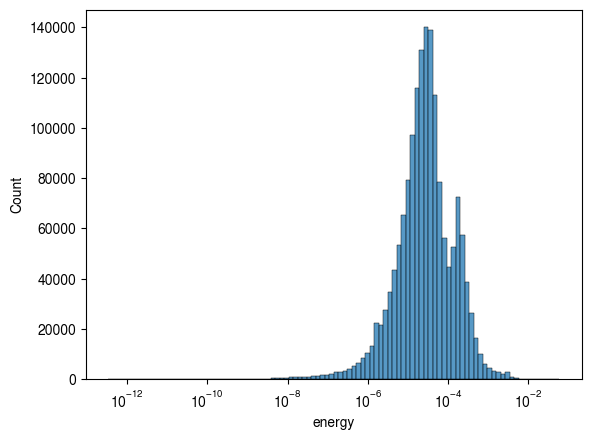

In [282]:
sns.histplot(hits_df.energy, log_scale=True, bins=100)

### Viz

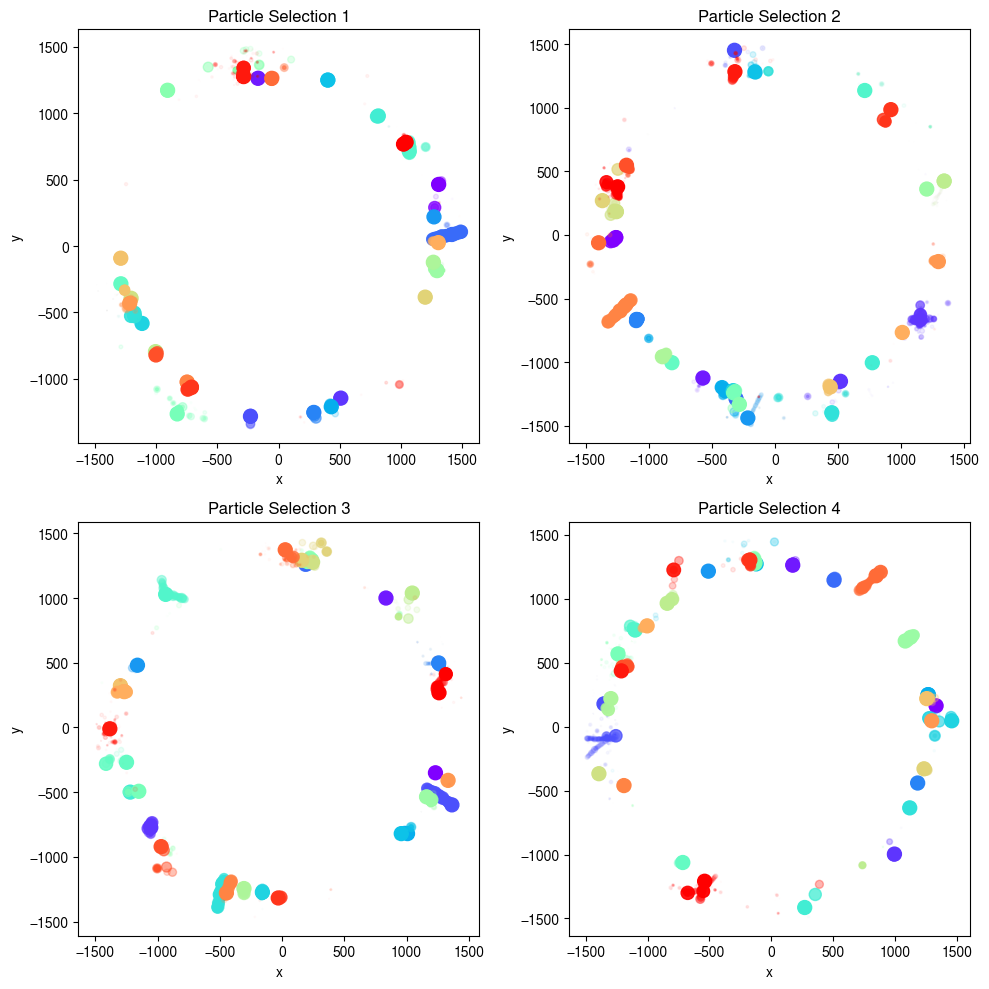

In [232]:
# Plot 10 sets of high-hitting particles, with hit size weighted by energy, and color by particle ID

num_particles = 30
max_hit_size = 100
particle_selection = particle_ids[counts > 20]

# Create a 5x2 grid of subplots
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes = axes.flatten()

for plot_idx in range(4):
    # Get a new random selection of particles for each subplot
    plot_particle_selection = np.random.choice(particle_selection, num_particles)
    
    # Use plt.cm instead of matplotlib.colors for colormaps. Use a rainbow color map
    particle_colors = plt.cm.rainbow(np.linspace(0, 1, len(plot_particle_selection)))
    
    for i, particle_id in enumerate(plot_particle_selection):
        particle_hits = hits_df[hits_df.particle_id == particle_id]
        hit_sizes = (particle_hits.energy)
        normalized_sizes = hit_sizes / hit_sizes.max()
        hit_sizes = normalized_sizes * max_hit_size
        axes[plot_idx].scatter(particle_hits.x, particle_hits.y, 
                   s=hit_sizes, 
                   alpha=normalized_sizes,
                   c=[particle_colors[i]], 
                   label=f"Particle {particle_id}")
    axes[plot_idx].set_xlabel('x')
    axes[plot_idx].set_ylabel('y')
    axes[plot_idx].set_title(f'Particle Selection {plot_idx+1}')

plt.tight_layout()
plt.show()


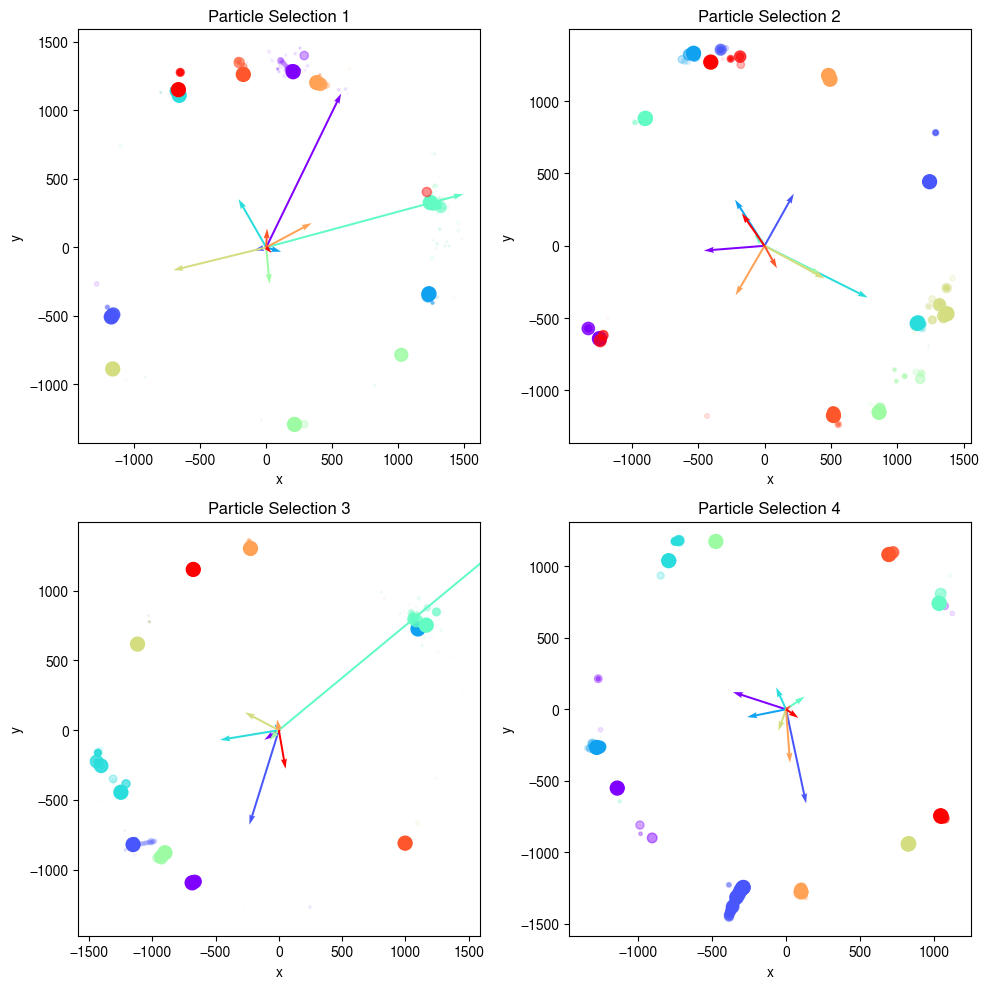

In [233]:
# Plot 10 sets of high-hitting particles, with hit size weighted by energy, and color by particle ID

num_particles = 10
max_hit_size = 100
particle_selection = particle_ids[counts > 20]

# Create a 5x2 grid of subplots
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes = axes.flatten()

for plot_idx in range(4):
    # Get a new random selection of particles for each subplot
    plot_particle_selection = np.random.choice(particle_selection, num_particles)
    
    # Use plt.cm instead of matplotlib.colors for colormaps. Use a rainbow color map
    particle_colors = plt.cm.rainbow(np.linspace(0, 1, len(plot_particle_selection)))
    
    for i, particle_id in enumerate(plot_particle_selection):
        particle_hits = hits_df[hits_df.particle_id == particle_id]
        hit_sizes = (particle_hits.energy)
        normalized_sizes = hit_sizes / hit_sizes.max()
        hit_sizes = normalized_sizes * max_hit_size
        
        # Plot the hits
        axes[plot_idx].scatter(particle_hits.x, particle_hits.y, 
                   s=hit_sizes, 
                   alpha=normalized_sizes,
                   c=[particle_colors[i]], 
                   label=f"Particle {particle_id}")
        
        # Get the particle momentum from particles_df
        particle = particles_df[particles_df.index == particle_id]
        if not particle.empty:
            # Calculate vector magnitudes and normalize
            px = particle.px.values
            py = particle.py.values
            magnitude = np.sqrt(px**2 + py**2)
            if magnitude > 0:
                # Scale factor to make vectors visible but not overwhelming
                scale_factor = 1000.0
                normalized_px = px * scale_factor
                normalized_py = py * scale_factor
                
                # Plot momentum vector from mean position of hits
                axes[plot_idx].quiver(0, 0,
                                    normalized_px, normalized_py,
                                    angles='xy', scale_units='xy', scale=1,
                                    width=0.005,
                                    color=particle_colors[i])
                
    axes[plot_idx].set_xlabel('x')
    axes[plot_idx].set_ylabel('y')
    axes[plot_idx].set_title(f'Particle Selection {plot_idx+1}')

plt.tight_layout()
plt.show()


In [184]:
particle

,PDG,generatorStatus,simulatorStatus,charge,time,mass,vx,vy,vz,px,...,endpoint_y,endpoint_z,parents_begin,parents_end,daughters_begin,daughters_end,pt,p,eta,phi
1508822,22,0,1426063360,0.0,5.905765,0.0,-1112.157584,375.857752,-625.21847,-0.037595,...,458.386577,-680.120536,1687826,1687827,1796145,1796145,0.051066,0.056003,-0.436249,2.398228


In [188]:
particles_df

,PDG,generatorStatus,simulatorStatus,charge,time,mass,vx,vy,vz,px,...,endpoint_y,endpoint_z,parents_begin,parents_end,daughters_begin,daughters_end,pt,p,eta,phi
0,2212,4,0,1.000000,0.000000,0.938270,0.000000,0.000000,0.000000,0.000000,...,-0.008542,26.856635,0,0,0,18,0.000000,7000.000000,inf,0.000000
1,2,61,0,0.666667,-7.935021,0.000000,0.014350,-0.008542,26.856635,4.007885,...,-0.008542,26.856635,0,1,18,19,4.355587,2498.030518,7.044945,0.402280
2,21,61,0,0.000000,-7.935021,0.000000,0.014350,-0.008542,26.856635,1.883551,...,-0.008542,26.856635,1,2,19,20,1.935166,95.593460,4.592956,-0.231480
3,2,61,0,0.666667,-7.935021,0.000000,0.014350,-0.008542,26.856635,-0.940797,...,-0.008542,26.856635,2,3,20,21,1.324849,91.695381,4.930268,2.360460
4,21,61,0,0.000000,-7.935021,0.000000,0.014350,-0.008542,26.856635,-1.318664,...,-0.008542,26.856635,3,4,21,22,1.343657,36.400036,3.991981,2.948416
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4114874,22,0,1426063360,0.000000,177.522324,0.000000,521.940814,956.793843,3201.391581,0.002517,...,1479.347154,3028.994501,4293878,4293879,4293883,4293883,0.006264,0.006543,-0.297689,1.157277
4114875,11,0,1493172224,-1.000000,17.498556,0.000511,-1165.143869,183.097628,-369.175184,-0.000946,...,182.620454,-370.581445,4293879,4293880,4293883,4293883,0.000955,0.002000,-1.370053,-3.004372
4114876,11,0,1493172224,-1.000000,4.289351,0.000511,569.750946,939.917389,3249.264699,0.000297,...,938.046192,3249.443308,4293880,4293881,4293883,4293883,0.001489,0.001489,0.014154,-1.370055
4114877,11,0,1493172224,-1.000000,4.504158,0.000511,382.543487,1003.334499,3302.579235,-0.000974,...,1003.345918,3302.591358,4293881,4293882,4293883,4293883,0.001314,0.001563,0.606236,-2.405629


In [191]:
tracker_df = pd.merge(tracker_df, particles_df[["charge"]], left_on='particle_id', right_index=True, how='left')

In [192]:
tracker_df[tracker_df.charge == 0]

,cellID,EDep,time,pathLength,quality,x,y,z,px,py,pz,particle_id,r,phi,pt,detector,charge
245,6529642467878,0.000011,353.796875,0.001857,1073741824,-67.582804,91.539965,-103.987935,-0.000043,6.580864e-06,-0.000033,117704,113.784887,2.206759,0.000043,PixelBarrelReadout,0.0
636,273435401981494,0.000022,19.147099,0.005872,1073741824,71.464827,154.210750,-404.609803,-0.000068,2.072316e-05,0.000028,160217,169.965223,1.136836,0.000071,PixelBarrelReadout,0.0
820,265943436100902,0.000012,34.837925,0.001938,1073741824,95.974004,62.629440,242.419692,-0.000055,-6.493605e-07,-0.000002,95592,114.601292,0.578177,0.000055,PixelBarrelReadout,0.0
1609,18075269202742,0.000014,237.794174,0.002619,1073741824,163.215959,46.237165,-458.098953,0.000025,4.300000e-05,0.000033,249604,169.638807,0.276055,0.000050,PixelBarrelReadout,0.0
2179,44395316055078,0.000172,67.296570,0.195977,1073741824,6.417081,113.335562,358.523425,-0.000030,2.111031e-04,0.000076,299278,113.517085,1.514237,0.000213,PixelBarrelReadout,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
259488,16569984921694,0.000144,30.579908,0.001020,1073741824,69.353640,797.758542,2979.451973,-0.005273,-4.194077e-02,-0.009374,4111617,800.767519,1.484079,0.042271,LongStripEndcapReadout,0.0
259495,1215476854798,0.000043,74.077950,0.018848,1073741824,-279.195244,784.566609,1279.462275,0.000072,-3.743328e-06,-0.000080,4112324,832.763321,1.912681,0.000072,LongStripEndcapReadout,0.0
259505,16883516633438,0.000015,10.012564,0.003051,1073741824,958.626770,-100.760023,3004.606546,-0.000031,-4.342845e-05,0.000032,4113166,963.907603,-0.104724,0.000054,LongStripEndcapReadout,0.0
259506,833224769870,0.000062,6.855611,0.118472,1073741824,-557.980983,911.346612,2620.623331,-0.000389,4.251955e-04,0.000110,4113486,1068.595070,2.120182,0.000576,LongStripEndcapReadout,0.0


In [186]:
particles_df.charge

0          1.000000
1          0.666667
2          0.000000
3          0.666667
4          0.000000
             ...   
4114874    0.000000
4114875   -1.000000
4114876   -1.000000
4114877   -1.000000
4114878   -1.000000
Name: charge, Length: 4114879, dtype: float32

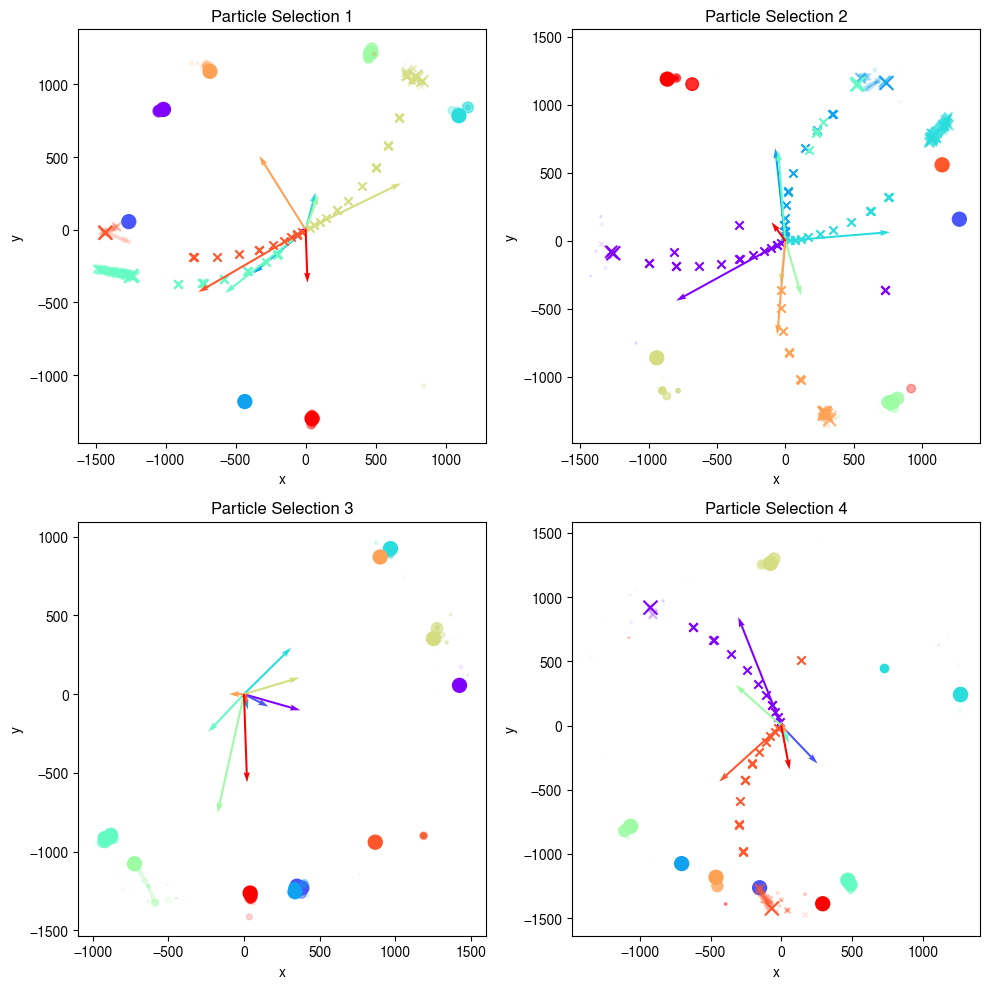

In [234]:
# Plot 10 sets of high-hitting particles, with hit size weighted by energy, and color by particle ID

num_particles = 10
max_hit_size = 100
particle_selection = particle_ids[counts > 20]

# Create a 5x2 grid of subplots
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes = axes.flatten()

for plot_idx in range(4):
    # Get a new random selection of particles for each subplot
    plot_particle_selection = np.random.choice(particle_selection, num_particles)
    
    # Use plt.cm instead of matplotlib.colors for colormaps. Use a rainbow color map
    particle_colors = plt.cm.rainbow(np.linspace(0, 1, len(plot_particle_selection)))
    
    for i, particle_id in enumerate(plot_particle_selection):
        # Get the particle momentum from particles_df
        particle = particles_df[particles_df.index == particle_id]
        if not particle.empty:
            # Calculate vector magnitudes and normalize
            px = particle.px.values
            py = particle.py.values
            magnitude = np.sqrt(px**2 + py**2)
            if magnitude > 0:
                # Scale factor to make vectors visible but not overwhelming
                scale_factor = 1000.0
                normalized_px = px * scale_factor
                normalized_py = py * scale_factor
                
                # Plot momentum vector from mean position of hits
                axes[plot_idx].quiver(0, 0,
                                    normalized_px, normalized_py,
                                    angles='xy', scale_units='xy', scale=1,
                                    width=0.005,
                                    color=particle_colors[i])
        
        particle_hits = hits_df[hits_df.particle_id == particle_id]
        tracker_hits = tracker_df[tracker_df.particle_id == particle_id]
        hit_sizes = (particle_hits.energy)
        normalized_sizes = hit_sizes / hit_sizes.max()
        hit_sizes = normalized_sizes * max_hit_size
        
        # Make the markers dependent on the charge of the particle (x for non-zero, o for zero)
        marker = 'x' if particle.charge.values[0] != 0 else 'o'

        # Plot the hits
        axes[plot_idx].scatter(particle_hits.x, particle_hits.y, 
                   s=hit_sizes, 
                   alpha=normalized_sizes,
                   c=[particle_colors[i]], 
                   marker=marker,
                   label=f"Particle {particle_id}")

        # Plot the tracker hits
        axes[plot_idx].scatter(tracker_hits.x, tracker_hits.y, 
                   c=[particle_colors[i]], 
                   marker=marker,
                   label=f"Particle {particle_id}")
        
        
                
    axes[plot_idx].set_xlabel('x')
    axes[plot_idx].set_ylabel('y')
    axes[plot_idx].set_title(f'Particle Selection {plot_idx+1}')

plt.tight_layout()
plt.show()


In [193]:
plot_particle_selection

array([ 337996,  647235, 1098872,  271557, 3012063,   41867, 2566636,
         30050, 2773771, 2207778], dtype=int32)

In [195]:
particles = particles_df[particles_df.index.isin(plot_particle_selection)]

### Decay Chain

In [203]:
tracker_df[tracker_df.particle_id == 2207778]

,cellID,EDep,time,pathLength,quality,x,y,z,px,py,pz,particle_id,r,phi,pt,detector,charge


In [202]:
hits_df[hits_df.particle_id == 2207778]

,PDG,energy,time,x,y,z,particle_id,detector,cell_x,cell_y,cell_z,cell_r,cell_phi,cell_eta
761974,0,2.716363e-04,9.335697,0.0,0.0,0.0,2207778,ECalBarrelCollection,1118.032959,573.508423,2340.899902,1256.546753,0.473963,1.380616
761975,0,3.044503e-04,9.364478,0.0,0.0,0.0,2207778,ECalBarrelCollection,1124.650269,570.729187,2340.899902,1261.177979,0.469608,1.377376
761976,0,2.467464e-04,9.394946,0.0,0.0,0.0,2207778,ECalBarrelCollection,1133.219238,563.238159,2340.899902,1265.473511,0.461265,1.374383
761977,0,3.770696e-04,9.426960,0.0,0.0,0.0,2207778,ECalBarrelCollection,1139.836548,560.458984,2340.899902,1270.173828,0.456987,1.371123
761978,0,2.868082e-04,9.462017,0.0,0.0,0.0,2207778,ECalBarrelCollection,1148.405518,552.967957,2340.899902,1274.601440,0.448746,1.368066
761979,0,2.658450e-04,9.496364,0.0,0.0,0.0,2207778,ECalBarrelCollection,1156.974487,545.476929,2340.899902,1279.114990,0.440563,1.364963
761980,0,2.708620e-04,9.528505,0.0,0.0,0.0,2207778,ECalBarrelCollection,1163.591675,542.697693,2340.899902,1283.926147,0.436407,1.361670
761981,0,2.591039e-04,9.560661,0.0,0.0,0.0,2207778,ECalBarrelCollection,1172.160645,535.206665,2340.899902,1288.567749,0.428328,1.358507
761982,0,2.861625e-04,9.592627,0.0,0.0,0.0,2207778,ECalBarrelCollection,1178.777954,532.427429,2340.899902,1293.443604,0.424248,1.355200
761983,0,2.290154e-04,9.624631,0.0,0.0,0.0,2207778,ECalBarrelCollection,1187.346924,524.936401,2340.899902,1298.210693,0.416272,1.351981


In [206]:
particles[particles.index == 2207778]

,PDG,generatorStatus,simulatorStatus,charge,time,mass,vx,vy,vz,px,...,endpoint_y,endpoint_z,parents_begin,parents_end,daughters_begin,daughters_end,pt,p,eta,phi
2207778,211,0,1157627904,1.0,8.819447,0.13957,987.201835,647.355382,2344.516426,0.528718,...,512.38877,2339.808797,2386782,2386783,2465344,2465346,0.604756,0.604986,-0.027606,-0.506872


In [208]:
parents_df.iloc[2386782]

index                45681
collectionID    2714477136
Name: 2386782, dtype: int64

In [210]:
particles_df.iloc[45681]

PDG                2.110000e+02
generatorStatus    1.000000e+00
simulatorStatus    1.509949e+08
charge             1.000000e+00
time               1.928970e-01
mass               1.395700e-01
vx                -9.888110e-03
vy                -1.486251e-02
vz                 7.857623e+01
px                 3.848026e-01
py                 6.776901e-01
pz                 1.430538e+00
endpoint_x         9.872018e+02
endpoint_y         6.473554e+02
endpoint_z         2.344516e+03
parents_begin      1.361490e+05
parents_end        1.361500e+05
daughters_begin    2.150260e+05
daughters_end      2.150440e+05
pt                 7.793182e-01
p                  1.629042e+00
eta                1.367614e+00
phi                1.054379e+00
Name: 45681, dtype: float64

In [211]:
tracker_df[tracker_df.particle_id == 45681]

,cellID,EDep,time,pathLength,quality,x,y,z,px,py,pz,particle_id,r,phi,pt,detector
26712,41986157970182,0.000083,0.424611,0.270929,0,16.663936,28.521301,139.233267,0.401019,0.668048,1.430135,45681,33.032580,1.042029,0.779169,PixelBarrelReadout
26713,30100255474966,0.000070,0.668268,0.262284,0,35.084899,58.113200,203.126492,0.421064,0.655870,1.428524,45681,67.882944,1.027636,0.779397,PixelBarrelReadout
26714,46112547932198,0.000071,0.989079,0.263241,0,60.381964,96.331966,287.277728,0.439828,0.640777,1.427805,45681,113.691817,1.010896,0.777202,PixelBarrelReadout
26715,270756098083894,0.000102,1.383848,0.266170,0,93.305428,141.834346,390.952251,0.466517,0.616533,1.427487,45681,169.773039,0.988924,0.773144,PixelBarrelReadout
125654,563134637999625,0.000122,2.022761,0.419918,0,150.549059,212.587537,558.590246,0.506413,0.583347,1.423212,45681,260.496603,0.954605,0.772495,ShortStripBarrelReadout
125655,71565399376857113,0.000116,2.733790,0.419071,0,219.853640,286.423837,745.251313,0.550686,0.541480,1.421464,45681,361.073728,0.916138,0.772305,ShortStripBarrelReadout
125656,896509999778601,0.000120,3.710549,0.420310,0,324.341573,378.340701,1001.624148,0.604011,0.477696,1.419923,45681,498.336374,0.862095,0.770080,ShortStripBarrelReadout
188258,15612206126603,0.000091,4.817927,0.284327,0,453.705565,468.154331,1292.500000,0.657232,0.399231,1.420288,45681,651.933446,0.801070,0.768986,ShortStripEndcapReadout
251178,16501265424414,0.000074,5.952425,0.284281,0,596.451646,543.021187,1590.500000,0.701978,0.314016,1.420009,45681,806.614267,0.738542,0.769012,LongStripEndcapReadout
251179,16488379473950,0.000102,5.971463,0.284359,0,598.925293,544.124048,1595.500000,0.702798,0.311281,1.418510,45681,809.186311,0.737492,0.768649,LongStripEndcapReadout


In [212]:
hits_df[hits_df.particle_id == 45681]

,PDG,energy,time,x,y,z,particle_id,detector


<Figure size 640x480 with 0 Axes>

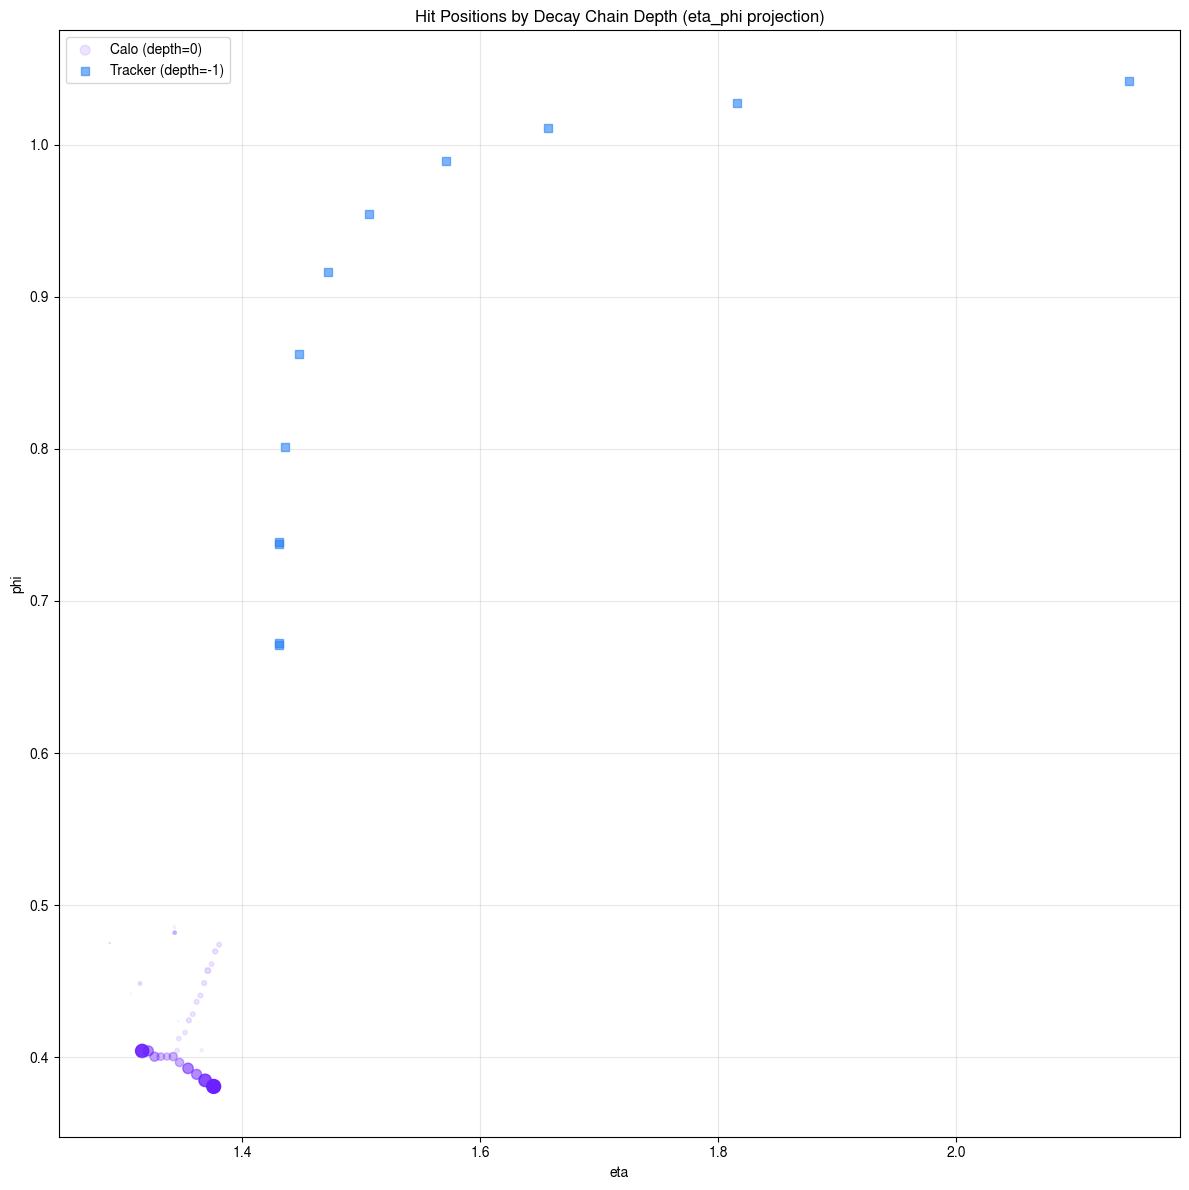

In [332]:
# Create and build the chain as before
chain = ParticleChain(particles_df, parents_df, daughters_df, tracker_df, hits_df)
viz = DecayChainViz(chain)
viz.build_chain(2207778, max_depth=10)

# Create multiple projections
plt.suptitle("Hit Distributions for Particle 2207778 Decay Chain")
viz.plot_hits(projection='eta_phi', max_depth=10)

plt.tight_layout()
plt.show()

### Final Visible Study

In [351]:
all_visible = particles_df[(particles_df.index.isin(hits_df.particle_id)) | (particles_df.index.isin(tracker_df.particle_id))]  

In [361]:
# Create chain as before
chain = ParticleChain(particles_df, parents_df, daughters_df, tracker_df, hits_df)

# Run analysis - now just one line!
chain.analyze_final_visible_particles()

100%|██████████| 44052/44052 [00:31<00:00, 1392.05it/s]


Summary:
Total particles with hits: 81903
Final visible particles (any detector): 51460
Final visible particles (calorimeter): 36481
Final visible particles (tracker): 29806
Analyzing ancestors with hits


  0%|          | 103/51460 [00:16<2:09:29,  6.61it/s]

KeyboardInterrupt: 

### Debug

In [288]:
viz.G.nodes[2207778]

{'pdg': 211.0,
 'pt': 0.604755699634552,
 'eta': -0.027606287971138954,
 'phi': -0.5068724751472473,
 'n_tracker_hits': 0,
 'n_calo_hits': 53}

In [290]:
# First, let's verify our particle exists and has hits
particle_id = 2207778

# 1. Check if particle exists in particles_df
print("1. Particle in particles_df:")
if particle_id in particles_df.index:
    print(particles_df.loc[particle_id])
else:
    print("Particle not found in particles_df")

# 2. Check direct hits
print("\n2. Direct hits:")
print("Tracker hits:", len(tracker_df[tracker_df.particle_id == particle_id]))
print("Calo hits:", len(hits_df[hits_df.particle_id == particle_id]))

# 3. Check parents and daughters
print("\n3. Parents and daughters:")
if particle_id in particles_df.index:
    particle = particles_df.loc[particle_id]
    print(f"Parents range: {particle.parents_begin} to {particle.parents_end}")
    print(f"Daughters range: {particle.daughters_begin} to {particle.daughters_end}")
    
    # Get actual parent IDs
    parent_indices = range(int(particle.parents_begin), int(particle.parents_end))
    parent_ids = parents_df.iloc[parent_indices].particle_id.tolist()
    print(f"Parent IDs: {parent_ids}")
    
    # Get actual daughter IDs
    daughter_indices = range(int(particle.daughters_begin), int(particle.daughters_end))
    daughter_ids = daughters_df.iloc[daughter_indices].particle_id.tolist()
    print(f"Daughter IDs: {daughter_ids}")

# 4. Check if graph was built correctly
print("\n4. Graph info:")
print(f"Number of nodes in graph: {len(viz.G.nodes())}")
print(f"Nodes in graph: {list(viz.G.nodes())}")
print(f"Number of edges in graph: {len(viz.G.edges())}")
print(f"Edges in graph: {list(viz.G.edges())}")

# 5. For each node in the graph, check its hits
print("\n5. Hits for each node in graph:")
for node in viz.G.nodes():
    hits = chain.get_detector_hits(node)
    print(f"\nNode {node}:")
    print(f"Tracker hits: {len(hits['tracker'])}")
    print(f"Calo hits: {len(hits['calo'])}")
    if len(hits['tracker']) > 0:
        print("Sample tracker hit:", hits['tracker'].iloc[0][['x', 'y', 'z', 'eta', 'phi']])
    if len(hits['calo']) > 0:
        print("Sample calo hit:", hits['calo'].iloc[0][['x', 'y', 'z']])

1. Particle in particles_df:
PDG                2.110000e+02
generatorStatus    0.000000e+00
simulatorStatus    1.157628e+09
charge             1.000000e+00
time               8.819447e+00
mass               1.395701e-01
vx                 9.872018e+02
vy                 6.473554e+02
vz                 2.344516e+03
px                 5.287180e-01
py                -2.935758e-01
pz                -1.669718e-02
endpoint_x         1.208022e+03
endpoint_y         5.123888e+02
endpoint_z         2.339809e+03
parents_begin      2.386782e+06
parents_end        2.386783e+06
daughters_begin    2.465344e+06
daughters_end      2.465346e+06
pt                 6.047557e-01
p                  6.049862e-01
eta               -2.760629e-02
phi               -5.068725e-01
Name: 2207778, dtype: float64

2. Direct hits:
Tracker hits: 0
Calo hits: 53

3. Parents and daughters:
Parents range: 2386782.0 to 2386783.0
Daughters range: 2465344.0 to 2465346.0
Parent IDs: [45681]
Daughter IDs: [2207826, 2207827]


In [291]:
# Let's check particle 45681 specifically
print("Checking particle 45681:")
print("\nIn particles_df:")
print(particles_df.iloc[45681])

print("\nTracker hits:")
print(tracker_df[tracker_df.particle_id == 45681].shape)

# Let's see how this particle is connected to 2207778
parent_indices = range(int(particles_df.loc[2207778].parents_begin), 
                      int(particles_df.loc[2207778].parents_end))
print("\nParent indices for 2207778:", list(parent_indices))
print("Parent IDs from parents_df:")
for idx in parent_indices:
    print(f"Particle ID {idx}: {parents_df.iloc[idx].particle_id}")

# Let's also check the parents_df directly
print("\nChecking parents_df for connection:")
print(parents_df.iloc[2386782])

Checking particle 45681:

In particles_df:
PDG                2.110000e+02
generatorStatus    1.000000e+00
simulatorStatus    1.509949e+08
charge             1.000000e+00
time               1.928970e-01
mass               1.395700e-01
vx                -9.888110e-03
vy                -1.486251e-02
vz                 7.857623e+01
px                 3.848026e-01
py                 6.776901e-01
pz                 1.430538e+00
endpoint_x         9.872018e+02
endpoint_y         6.473554e+02
endpoint_z         2.344516e+03
parents_begin      1.361490e+05
parents_end        1.361500e+05
daughters_begin    2.150260e+05
daughters_end      2.150440e+05
pt                 7.793182e-01
p                  1.629042e+00
eta                1.367614e+00
phi                1.054379e+00
Name: 45681, dtype: float64

Tracker hits:
(12, 19)

Parent indices for 2207778: [2386782]
Parent IDs from parents_df:
Particle ID 2386782: 45681

Checking parents_df for connection:
particle_id          45681
collectionI

In [292]:
# Let's check particle 45681's daughters
print("Checking daughters for particle 45681:")
daughter_indices = range(int(particles_df.loc[45681].daughters_begin), 
                        int(particles_df.loc[45681].daughters_end))
print("\nDaughter indices:", list(daughter_indices))
print("\nDaughter IDs from daughters_df:")
for idx in daughter_indices:
    print(f"Particle ID {idx}: {daughters_df.iloc[idx].particle_id}")

Checking daughters for particle 45681:

Daughter indices: [215026, 215027, 215028, 215029, 215030, 215031, 215032, 215033, 215034, 215035, 215036, 215037, 215038, 215039, 215040, 215041, 215042, 215043]

Daughter IDs from daughters_df:
Particle ID 215026: 2207775
Particle ID 215027: 2207776
Particle ID 215028: 2207777
Particle ID 215029: 2207778
Particle ID 215030: 2207779
Particle ID 215031: 2207780
Particle ID 215032: 2207781
Particle ID 215033: 2207782
Particle ID 215034: 2207783
Particle ID 215035: 2207784
Particle ID 215036: 2207785
Particle ID 215037: 2207786
Particle ID 215038: 2207787
Particle ID 215039: 2207788
Particle ID 215040: 2207789
Particle ID 215041: 2207790
Particle ID 215042: 2207791
Particle ID 215043: 2207792


### More Viz

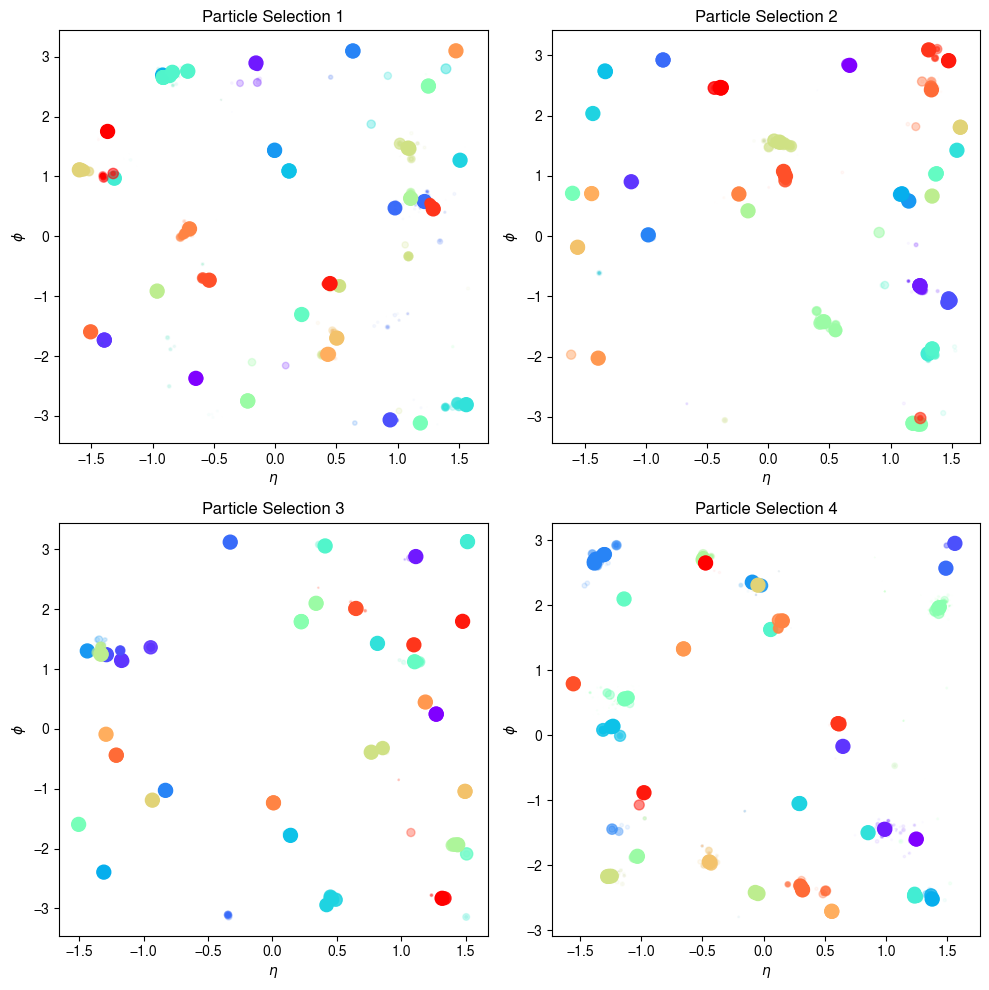

In [122]:
# Plot 10 sets of high-hitting particles, with hit size weighted by energy, and color by particle ID

num_particles = 30
max_hit_size = 100
particle_selection = particle_ids[counts > 20]

# Create a 5x2 grid of subplots
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes = axes.flatten()

for plot_idx in range(4):
    # Get a new random selection of particles for each subplot
    plot_particle_selection = np.random.choice(particle_selection, num_particles)
    
    # Use plt.cm instead of matplotlib.colors for colormaps. Use a rainbow color map
    particle_colors = plt.cm.rainbow(np.linspace(0, 1, len(plot_particle_selection)))
    
    for i, particle_id in enumerate(plot_particle_selection):
        particle_hits = hits_df[hits_df.particle_id == particle_id]
        hit_sizes = (particle_hits.energy)
        normalized_sizes = hit_sizes / hit_sizes.max()
        hit_sizes = normalized_sizes * max_hit_size
        axes[plot_idx].scatter(particle_hits.cell_eta, particle_hits.cell_phi, 
                   s=hit_sizes, 
                   alpha=normalized_sizes,
                   c=[particle_colors[i]], 
                   label=f"Particle {particle_id}")
    
    axes[plot_idx].set_title(f'Particle Selection {plot_idx+1}')
    axes[plot_idx].set_xlabel('$\eta$')
    axes[plot_idx].set_ylabel('$\phi$')

plt.legend().set_visible(False)
plt.tight_layout()
plt.show()


In [124]:
hits_df

,PDG,energy,time,x,y,z,particle_id,detector,cell_x,cell_y,cell_z,cell_r,cell_phi,cell_eta
0,0,1.836892e-09,2350.970459,35.700001,-1267.550049,357.000000,96703,ECalBarrelCollection,35.700001,-1267.550049,357.000000,1268.052734,-1.542639,0.277942
1,0,6.815690e-06,264.285522,1343.300049,61.200001,-2820.300049,96900,ECalBarrelCollection,1343.300049,61.200001,-2820.300049,1344.693481,0.045528,-1.486345
2,0,7.979669e-06,289.870026,1333.199951,61.200001,-2794.800049,96900,ECalBarrelCollection,1333.199951,61.200001,-2794.800049,1334.603882,0.045872,-1.484945
3,0,6.901636e-07,123.742516,1173.350220,-519.138733,-2473.500000,96897,ECalBarrelCollection,1173.350220,-519.138733,-2473.500000,1283.064941,-0.416550,-1.410875
4,0,4.109088e-06,103.411964,1441.609619,-359.765656,-2152.199951,97236,ECalBarrelCollection,1441.609619,-359.765656,-2152.199951,1485.822876,-0.244563,-1.165847
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1632715,0,1.236313e-08,1400.821411,418.368774,1329.878174,2963.100098,1850,ECalBarrelCollection,418.368774,1329.878174,2963.100098,1394.133545,1.266007,1.498352
1632716,0,1.204739e-05,4.557359,538.703430,1247.237427,3034.500000,1850,ECalBarrelCollection,538.703430,1247.237427,3034.500000,1358.603149,1.163081,1.543454
1632717,0,1.023659e-04,558.242371,224.399994,1484.699951,3049.800049,1850,ECalBarrelCollection,224.399994,1484.699951,3049.800049,1501.562256,1.420790,1.457451
1632718,0,7.743286e-05,558.243347,224.399994,1484.699951,3049.800049,1850,ECalBarrelCollection,224.399994,1484.699951,3049.800049,1501.562256,1.420790,1.457451


In [125]:
particles_df

,PDG,generatorStatus,simulatorStatus,charge,time,mass,vx,vy,vz,px,...,endpoint_y,endpoint_z,parents_begin,parents_end,daughters_begin,daughters_end,pt,p,eta,phi
0,2212,4,0,1.000000,0.000000,0.938270,0.000000,0.000000,0.000000,0.000000,...,-0.008542,26.856635,0,0,0,18,0.000000,7000.000000,inf,0.000000
1,2,61,0,0.666667,-7.935021,0.000000,0.014350,-0.008542,26.856635,4.007885,...,-0.008542,26.856635,0,1,18,19,4.355587,2498.030518,7.044945,0.402280
2,21,61,0,0.000000,-7.935021,0.000000,0.014350,-0.008542,26.856635,1.883551,...,-0.008542,26.856635,1,2,19,20,1.935166,95.593460,4.592956,-0.231480
3,2,61,0,0.666667,-7.935021,0.000000,0.014350,-0.008542,26.856635,-0.940797,...,-0.008542,26.856635,2,3,20,21,1.324849,91.695381,4.930268,2.360460
4,21,61,0,0.000000,-7.935021,0.000000,0.014350,-0.008542,26.856635,-1.318664,...,-0.008542,26.856635,3,4,21,22,1.343657,36.400036,3.991981,2.948416
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4114874,22,0,1426063360,0.000000,177.522324,0.000000,521.940814,956.793843,3201.391581,0.002517,...,1479.347154,3028.994501,4293878,4293879,4293883,4293883,0.006264,0.006543,-0.297689,1.157277
4114875,11,0,1493172224,-1.000000,17.498556,0.000511,-1165.143869,183.097628,-369.175184,-0.000946,...,182.620454,-370.581445,4293879,4293880,4293883,4293883,0.000955,0.002000,-1.370053,-3.004372
4114876,11,0,1493172224,-1.000000,4.289351,0.000511,569.750946,939.917389,3249.264699,0.000297,...,938.046192,3249.443308,4293880,4293881,4293883,4293883,0.001489,0.001489,0.014154,-1.370055
4114877,11,0,1493172224,-1.000000,4.504158,0.000511,382.543487,1003.334499,3302.579235,-0.000974,...,1003.345918,3302.591358,4293881,4293882,4293883,4293883,0.001314,0.001563,0.606236,-2.405629


In [140]:
particle[1].px

-0.0006396043463610113

In [149]:
magnitudes

2775748    0.011348
3885301    0.004648
1309137    0.411155
3075025    0.002400
3412319    0.002052
2338798    0.001706
1829909    0.003019
1853941    0.004781
1077161    0.002479
2868153    0.002111
dtype: float32

(-1.2, 1.2)

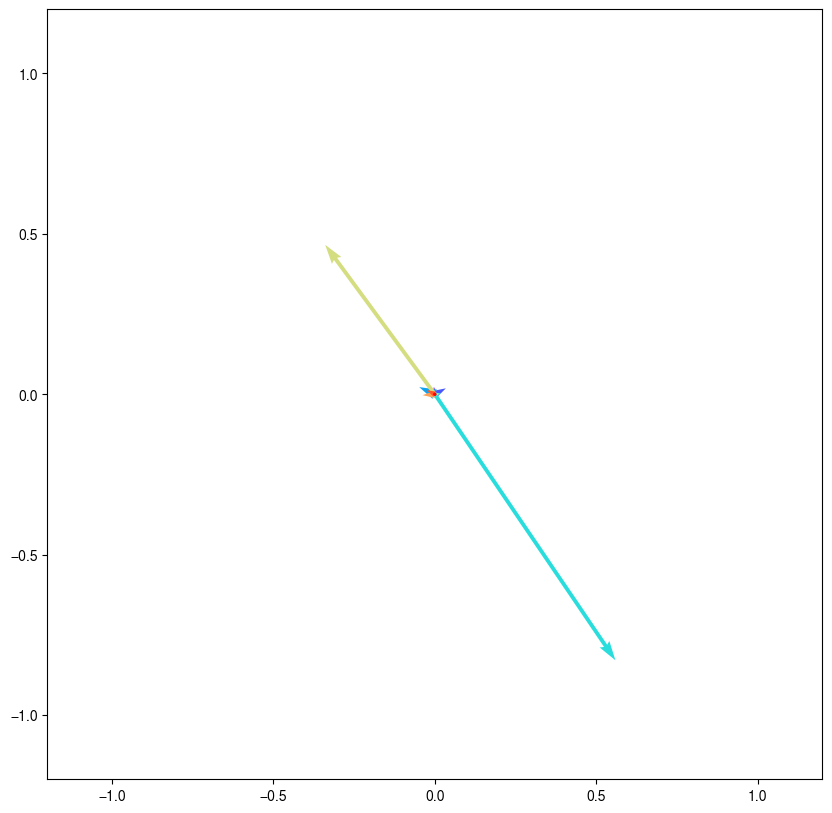

In [166]:
# Select a few random entries from particles_df and plot their momentum vectors
particles_selection = particles_df.sample(10)
colors = plt.cm.rainbow(np.linspace(0, 1, len(particles_selection)))

# Create arrays of zeros for starting points
zeros_x = np.zeros(len(particles_selection))
zeros_y = np.zeros(len(particles_selection))

# Calculate vector magnitudes and normalize
magnitudes = np.sqrt(particles_selection.px**2 + particles_selection.py**2)
# If the magnitudes are very small, we should scale them up
scale_factor = 1.0 / magnitudes.max()  # This will make the largest vector unit length
normalized_px = particles_selection.px * scale_factor
normalized_py = particles_selection.py * scale_factor

# Create the quiver plot
plt.figure(figsize=(10, 10))
plt.quiver(zeros_x, zeros_y, 
          normalized_px, normalized_py,
          angles='xy', scale_units='xy', scale=1,
          width=0.005,
          color=colors)  # Adjust arrow width if needed

# Set limits with small padding
plt.xlim(-1.2, 1.2)
plt.ylim(-1.2, 1.2)

# plt.show()

### Hit to Particle Matching

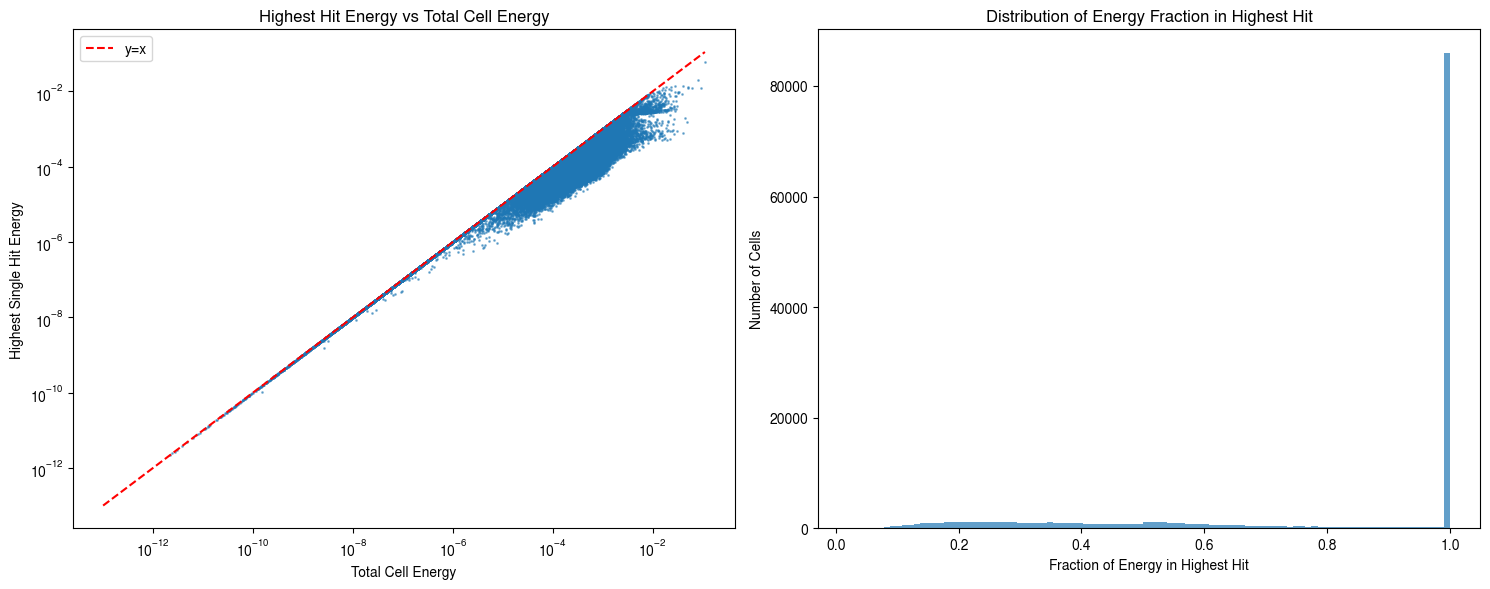


Fraction of energy in highest hit:
count    148376.000000
mean          0.758763
std           0.315306
min           0.020042
25%           0.468021
50%           1.000000
75%           1.000000
max           1.000000
dtype: float64


In [380]:
# 1. Get highest energy hit per cell
highest_energy_hits = hits_df.groupby('cellID').energy.max().reset_index()

# 2. Merge with cell energies
energy_comparison = pd.merge(
    highest_energy_hits,
    cells_df[['cellID', 'energy']],
    on='cellID',
    suffixes=('_max', '_total')
)
# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# 1. Scatter plot
ax1.scatter(energy_comparison.energy_total, 
          energy_comparison.energy_max, 
          alpha=0.5, 
          s=1)
ax1.set_xlabel('Total Cell Energy')
ax1.set_ylabel('Highest Single Hit Energy')
ax1.set_yscale('log')
ax1.set_xscale('log')

# Add y=x line
max_val = max(energy_comparison.energy_total.max(), 
             energy_comparison.energy_max.max())
ax1.plot([1e-13, max_val], [1e-13, max_val], 
        'r--', label='y=x')
ax1.legend()
ax1.set_title('Highest Hit Energy vs Total Cell Energy')

# 2. Histogram of fractions
fractions = energy_comparison.energy_max / energy_comparison.energy_total
ax2.hist(fractions, bins=100, alpha=0.7)
ax2.set_xlabel('Fraction of Energy in Highest Hit')
ax2.set_ylabel('Number of Cells')
ax2.set_title('Distribution of Energy Fraction in Highest Hit')

plt.tight_layout()
plt.show()

# Print statistics
print("\nFraction of energy in highest hit:")
print(fractions.describe())

<Axes: ylabel='Count'>

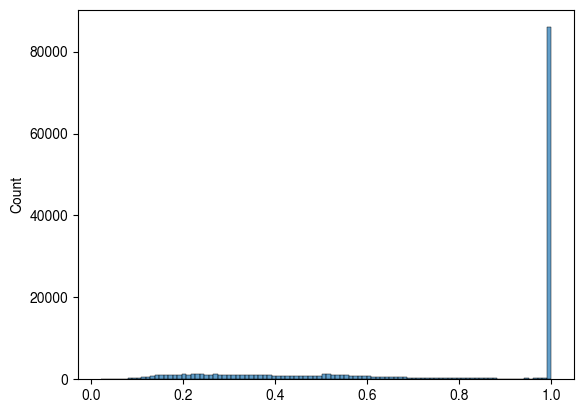

In [381]:
sns.histplot(fractions, bins=100, alpha=0.7)

<Axes: xlabel='energy', ylabel='Count'>

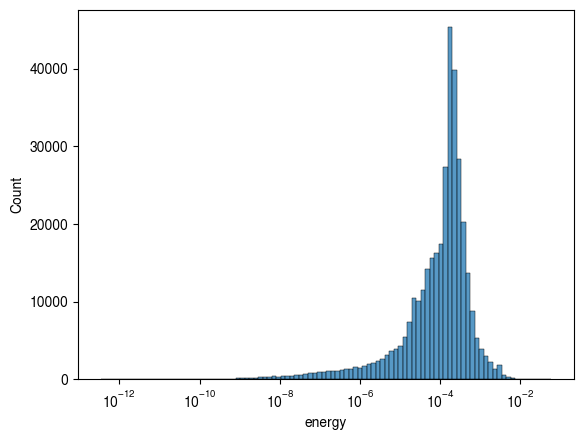

In [385]:
sns.histplot(highest_energy_hits.energy, bins=100, log_scale=True)

<Axes: xlabel='energy_total', ylabel='Count'>

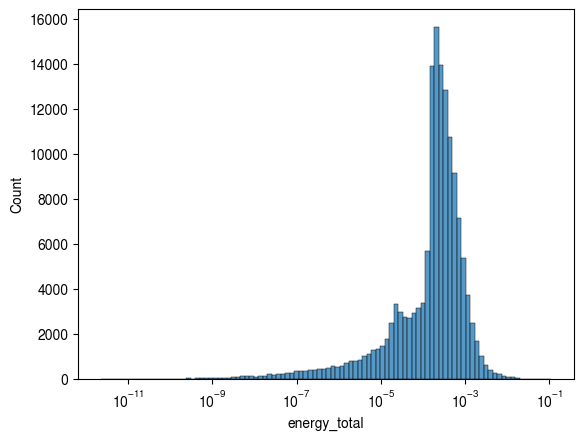

In [390]:
sns.histplot(energy_comparison.energy_total, bins=100, log_scale=True)

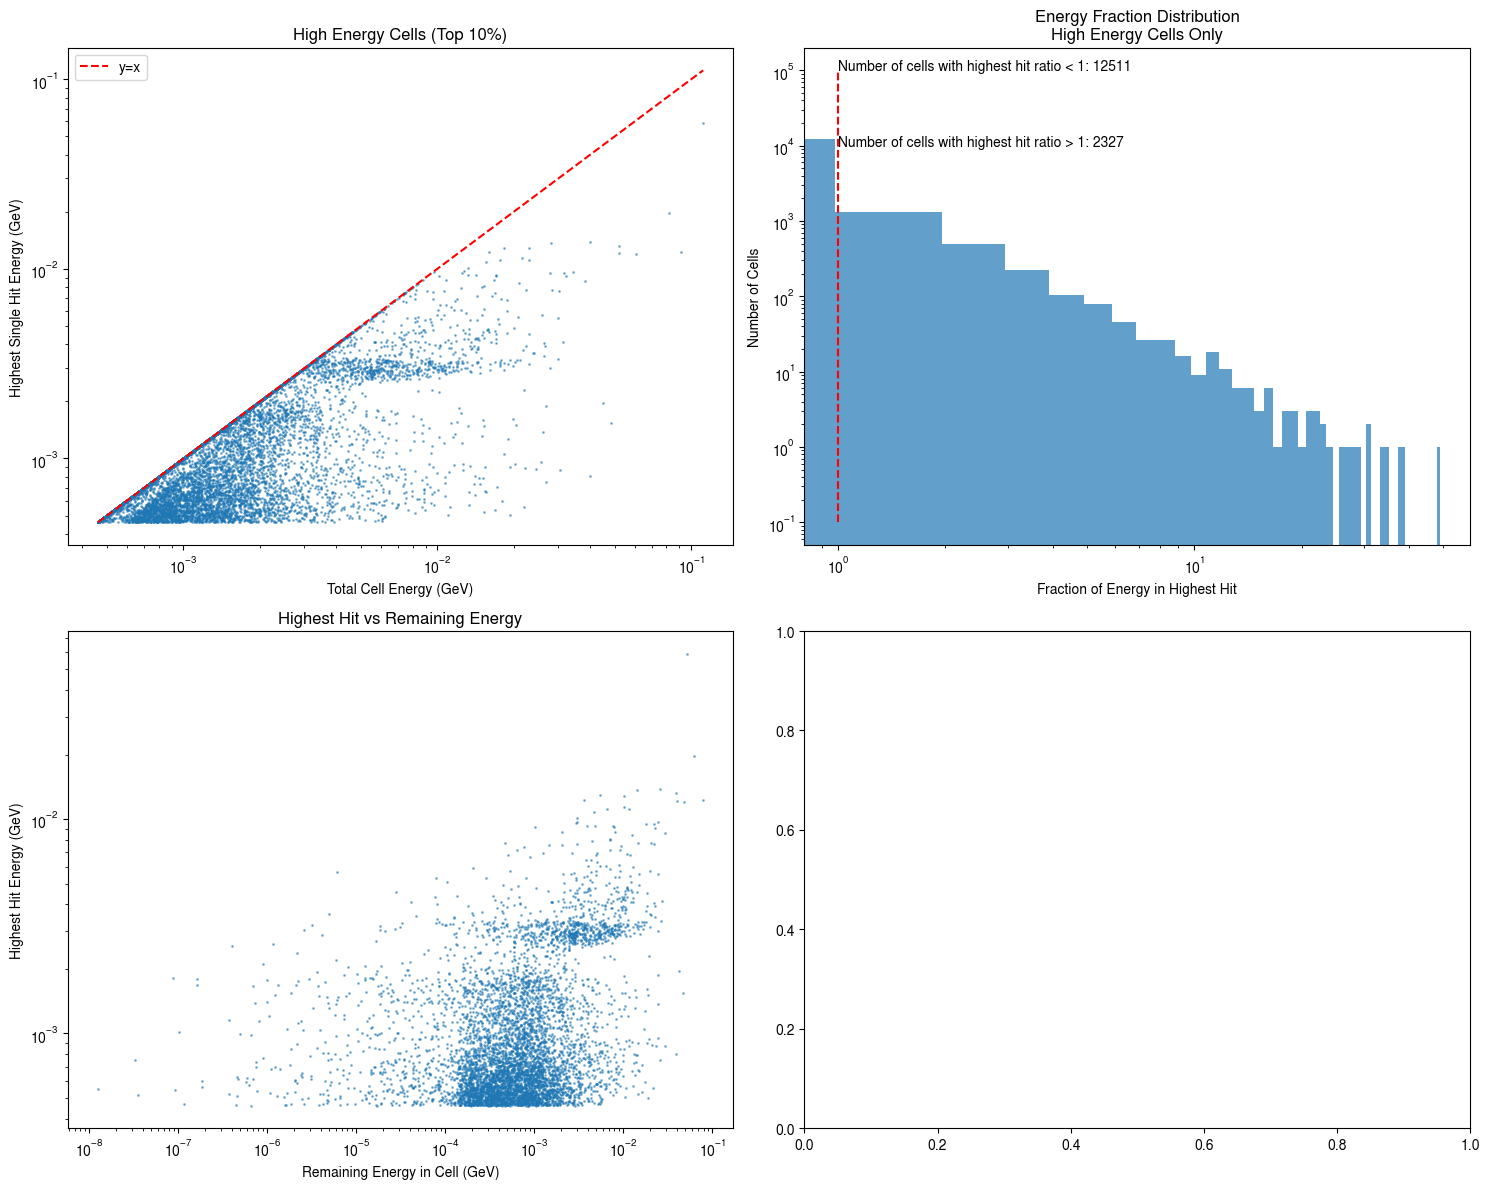


Analysis of cells with energy > 4.60e-04:
Number of cells: 14838

Ratio statistics (highest hit / total energy):
count    14838.000000
mean         0.572382
std          1.717554
min          0.000000
25%          0.000000
50%          0.000000
75%          0.550948
max         48.895828
Name: highest_hit_ratio, dtype: float64

Median remaining energy: 0.0


In [401]:
# Calculate the 90th percentile threshold for total cell energy
energy_threshold = energy_comparison.energy_max.quantile(0.9)

# Filter for high energy cells
high_energy = energy_comparison[energy_comparison.energy_max > energy_threshold].copy()

# Calculate ratios for high energy cells
high_energy['remaining_energy'] = high_energy.energy_total - high_energy.energy_max
high_energy['highest_hit_ratio'] = high_energy.remaining_energy / high_energy.energy_max

# Create figure with multiple views
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))

# 1. Scatter plot of high energy cells only
ax1.scatter(high_energy.energy_total, 
           high_energy.energy_max, 
           alpha=0.5, 
           s=1)
ax1.plot([energy_threshold, max_val], [energy_threshold, max_val], 
         'r--', label='y=x')
ax1.set_xlabel('Total Cell Energy (GeV)')
ax1.set_ylabel('Highest Single Hit Energy (GeV)')
ax1.set_yscale('log')
ax1.set_xscale('log')
ax1.legend()
ax1.set_title('High Energy Cells (Top 10%)')

# 2. Histogram of energy fractions for high energy cells
ax2.hist(high_energy.highest_hit_ratio, bins=50, alpha=0.7)
ax2.set_xlabel('Fraction of Energy in Highest Hit')
ax2.set_ylabel('Number of Cells')
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_title('Energy Fraction Distribution\nHigh Energy Cells Only')

# Add to ax2 a line at x=1, and add a textbox with the number of cells with a highest hit ratio of less than 1
ax2.plot([1, 1], [1e-1, 1e5], 'r--')
ax2.text(1, 1e5, f"Number of cells with highest hit ratio < 1: {len(high_energy[high_energy.highest_hit_ratio < 1])}")
ax2.text(1, 1e4, f"Number of cells with highest hit ratio > 1: {len(high_energy[high_energy.highest_hit_ratio > 1])}")

# 3. Scatter of highest hit vs remaining energy
ax3.scatter(high_energy.remaining_energy, 
           high_energy.energy_max, 
           alpha=0.5, 
           s=1)
ax3.set_xlabel('Remaining Energy in Cell (GeV)')
ax3.set_ylabel('Highest Hit Energy (GeV)')
ax3.set_yscale('log')
ax3.set_xscale('log')
ax3.set_title('Highest Hit vs Remaining Energy')

plt.tight_layout()
plt.show()

# Print statistics
print(f"\nAnalysis of cells with energy > {energy_threshold:.2e}:")
print(f"Number of cells: {len(high_energy)}")
print("\nRatio statistics (highest hit / total energy):")
print(high_energy.highest_hit_ratio.describe())
print("\nMedian remaining energy:", high_energy.remaining_energy.median())

In [414]:
# Let's visualize a case of a cell with a highest hit ratio of around 10:
merged_cell_id = high_energy[(high_energy.highest_hit_ratio > 10) & (high_energy.energy_max > 0.001)].iloc[0].cellID
merged_cell = cells_df[cells_df.cellID == merged_cell_id]

In [415]:
merged_cell

,cellID,energy,x,y,z,contribution_begin,contribution_end,r,R,phi,theta,eta,detector
340722,117656368474892304,0.048577,-1249.130981,-296.598969,2126.699951,1512868,1513155,1283.861084,2484.18042,-2.908466,0.543126,1.278547,ECalBarrelCollection


In [416]:
merged_hits = hits_df[hits_df.cellID == merged_cell_id]
merged_hits


,PDG,energy,time,x,y,z,particle_id,detector,r,phi,eta,cellID
1512868,0,0.000186,0.280900,-1249.130981,-296.598969,2126.699951,4049239,ECalBarrelCollection,1283.861084,-2.908466,1.278547,1.176564e+17
1512869,0,0.000365,0.276631,-1249.130981,-296.598969,2126.699951,4049239,ECalBarrelCollection,1283.861084,-2.908466,1.278547,1.176564e+17
1512870,0,0.000291,0.277058,-1249.130981,-296.598969,2126.699951,4049239,ECalBarrelCollection,1283.861084,-2.908466,1.278547,1.176564e+17
1512871,0,0.000335,0.275086,-1249.130981,-296.598969,2126.699951,4049239,ECalBarrelCollection,1283.861084,-2.908466,1.278547,1.176564e+17
1512872,0,0.000065,0.272088,-1249.130981,-296.598969,2126.699951,4049239,ECalBarrelCollection,1283.861084,-2.908466,1.278547,1.176564e+17
...,...,...,...,...,...,...,...,...,...,...,...,...
1513150,0,0.000020,0.277613,-1249.130981,-296.598969,2126.699951,4049238,ECalBarrelCollection,1283.861084,-2.908466,1.278547,1.176564e+17
1513151,0,0.000006,0.277685,-1249.130981,-296.598969,2126.699951,4049238,ECalBarrelCollection,1283.861084,-2.908466,1.278547,1.176564e+17
1513152,0,0.000002,0.277735,-1249.130981,-296.598969,2126.699951,4049238,ECalBarrelCollection,1283.861084,-2.908466,1.278547,1.176564e+17
1513153,0,0.000261,0.279208,-1249.130981,-296.598969,2126.699951,4049238,ECalBarrelCollection,1283.861084,-2.908466,1.278547,1.176564e+17


In [417]:
hits_df

,PDG,energy,time,x,y,z,particle_id,detector,r,phi,eta,cellID
0,0,1.836892e-09,2350.970459,35.700001,-1267.550049,357.000000,96703,ECalBarrelCollection,1268.052734,-1.542639,0.277942,1.970328e+16
1,0,6.815690e-06,264.285522,1343.300049,61.200001,-2820.300049,96900,ECalBarrelCollection,1344.693481,0.045528,-1.486345,1.829109e+19
2,0,7.979669e-06,289.870026,1333.199951,61.200001,-2794.800049,96900,ECalBarrelCollection,1334.603882,0.045872,-1.484945,1.829250e+19
3,0,6.901636e-07,123.742516,1173.350220,-519.138733,-2473.500000,96897,ECalBarrelCollection,1283.064941,-0.416550,-1.410875,1.831051e+19
4,0,4.109088e-06,103.411964,1441.609619,-359.765656,-2152.199951,97236,ECalBarrelCollection,1485.822876,-0.244563,-1.165847,1.832796e+19
...,...,...,...,...,...,...,...,...,...,...,...,...
1632715,0,1.236313e-08,1400.821411,418.368774,1329.878174,2963.100098,1850,ECalBarrelCollection,1394.133545,1.266007,1.498352,1.635371e+17
1632716,0,1.204739e-05,4.557359,538.703430,1247.237427,3034.500000,1850,ECalBarrelCollection,1358.603149,1.163081,1.543454,1.677591e+17
1632717,0,1.023659e-04,558.242371,224.399994,1484.699951,3049.800049,1850,ECalBarrelCollection,1501.562256,1.420790,1.457451,1.686033e+17
1632718,0,7.743286e-05,558.243347,224.399994,1484.699951,3049.800049,1850,ECalBarrelCollection,1501.562256,1.420790,1.457451,1.686033e+17


In [420]:
particle_total_hits

,cellID,particle_id,energy,time,x,y,z,PDG,detector
0,8.505360e+06,84029,0.000206,10.330897,-483.137848,1166.397949,-6.528063e-15,0,ECalBarrelCollection
1,8.669200e+06,84029,0.002675,10.714758,-492.800598,1189.725830,-5.011655e-15,0,ECalBarrelCollection
2,4.303493e+09,2082713,0.000381,5.583194,-480.358612,-1173.015137,-5.103619e-15,0,ECalBarrelCollection
3,4.303505e+09,84029,0.000214,10.355533,-489.782166,1169.111816,-6.910275e-15,0,ECalBarrelCollection
4,4.303561e+09,28900,0.000034,5.439730,-899.828735,-907.041199,-2.922809e-15,0,ECalBarrelCollection
...,...,...,...,...,...,...,...,...,...
362180,1.844674e+19,84029,0.000035,10.408234,-467.069916,1167.587402,-5.100000e+00,0,ECalBarrelCollection
362181,1.844674e+19,1598387,0.000467,7.953713,-1202.533203,514.666138,-5.100000e+00,0,ECalBarrelCollection
362182,1.844674e+19,84029,0.000595,10.310396,-471.781708,1165.635742,-5.100000e+00,0,ECalBarrelCollection
362183,1.844674e+19,63334,0.000194,10.397223,-523.482239,-1237.144043,-5.100000e+00,0,ECalBarrelCollection



Particles per cell statistics:
count    355600.000000
mean          1.018518
std           0.189644
min           1.000000
25%           1.000000
50%           1.000000
75%           1.000000
max          12.000000
dtype: float64

Hits per particle-cell combination statistics:
count    362185.000000
mean          4.507972
std           7.195535
min           1.000000
25%           1.000000
50%           1.000000
75%           5.000000
max         275.000000
dtype: float64


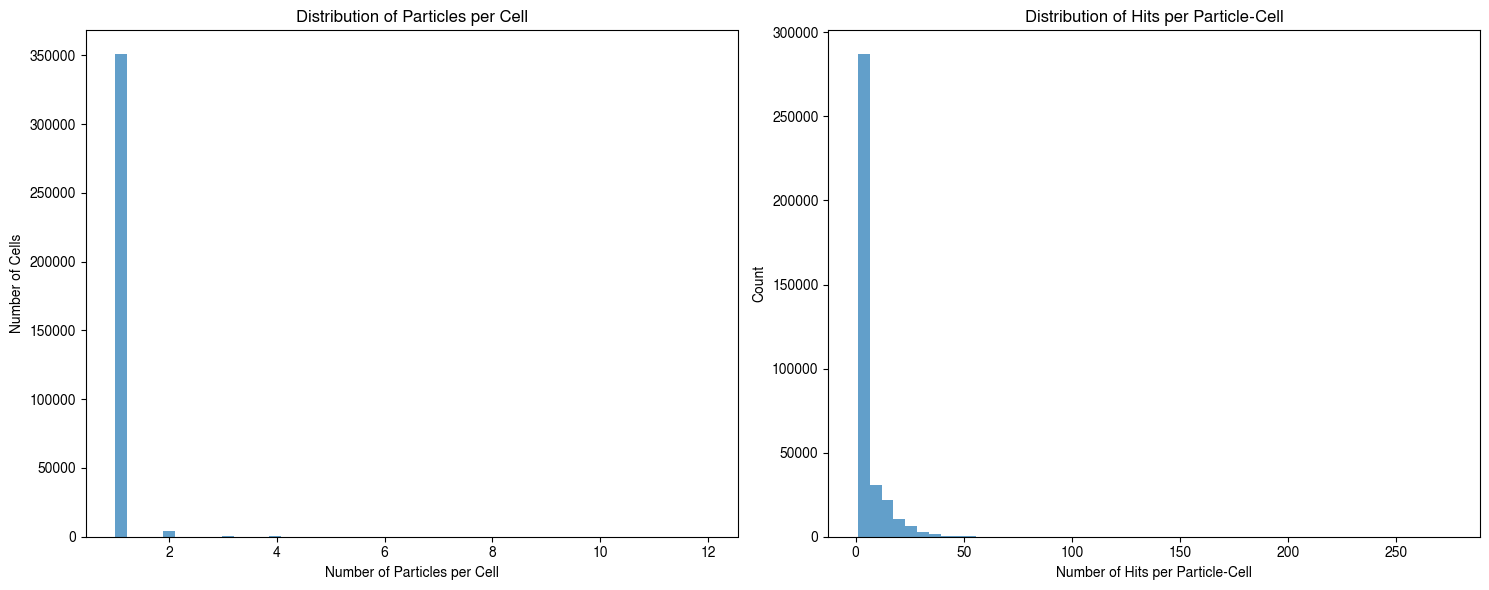

In [419]:
# Sum hits by both cell and particle ID
particle_total_hits = hits_df.groupby(['cellID', 'particle_id']).agg({
    'energy': 'sum',
    'time': 'mean',  # Take mean time of hits
    'x': 'first',    # Take position from first hit
    'y': 'first',
    'z': 'first',
    'detector': 'first'
}).reset_index()

# Now particle_total_hits contains one row per particle per cell, 
# with the total energy deposited by that particle in that cell

# Let's look at the distribution of number of particles per cell
particles_per_cell = particle_total_hits.groupby('cellID').size()
print("\nParticles per cell statistics:")
print(particles_per_cell.describe())

# And the distribution of number of hits that were merged
hits_per_particle_cell = hits_df.groupby(['cellID', 'particle_id']).size()
print("\nHits per particle-cell combination statistics:")
print(hits_per_particle_cell.describe())

# Create visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot distribution of particles per cell
ax1.hist(particles_per_cell, bins=50, alpha=0.7)
ax1.set_xlabel('Number of Particles per Cell')
ax1.set_ylabel('Number of Cells')
ax1.set_title('Distribution of Particles per Cell')

# Plot distribution of hits per particle-cell combination
ax2.hist(hits_per_particle_cell, bins=50, alpha=0.7)
ax2.set_xlabel('Number of Hits per Particle-Cell')
ax2.set_ylabel('Count')
ax2.set_title('Distribution of Hits per Particle-Cell')

plt.tight_layout()
plt.show()

### Clustering Performance

In [6]:
# Sum hits by both cell and particle ID
particle_total_hits = hits_df.groupby(['cellID', 'particle_id']).agg({
    'energy': 'sum',
    'time': 'mean',  # Take mean time of hits
    'x': 'first',    # Take position from first hit
    'y': 'first',
    'z': 'first',
    'detector': 'first'
}).reset_index()

In [10]:
highest_energy_particle = particle_total_hits.sort_values(by='energy', ascending=False).groupby('cellID').first()[['particle_id']].reset_index()
calo_hits_df = cells_df.merge(highest_energy_particle, on='cellID').rename(columns={'particle_id': 'highest_energy_particle_id'})
calo_hits_df

,cellID,energy,x,y,z,contribution_begin,contribution_end,r,R,phi,theta,eta,detector,highest_energy_particle_id
0,19703278443040784,1.836892e-09,35.700001,-1267.550049,357.000000,0,1,1268.052734,1317.348389,-1.542639,1.296366,0.277942,ECalBarrelCollection,96703
1,18291088463137206288,6.815690e-06,1343.300049,61.200001,-2820.300049,1,2,1344.693481,3124.466797,0.045528,2.696684,-1.486345,ECalBarrelCollection,96900
2,18292495838020694032,7.979669e-06,1333.199951,61.200001,-2794.800049,2,3,1334.603882,3097.107422,0.045872,2.696081,-1.484945,ECalBarrelCollection,96900
3,18310510159220439056,6.901636e-07,1173.350220,-519.138733,-2473.500000,3,4,1283.064941,2786.477783,-0.416550,2.663078,-1.410875,ECalBarrelCollection,96897
4,18327961818231109648,4.109088e-06,1441.609619,-359.765656,-2152.199951,4,5,1485.822876,2615.269287,-0.244563,2.537356,-1.165847,ECalBarrelCollection,97236
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
355595,168322186405959696,3.216178e-07,354.943817,1323.353149,3049.800049,1632713,1632714,1370.127197,3343.430664,1.308748,0.422231,1.540336,ECalBarrelCollection,1850
355596,163255602465495056,7.675362e-07,396.503204,1317.070801,2958.000000,1632714,1632715,1375.459961,3262.154785,1.278377,0.435255,1.509007,ECalBarrelCollection,1850
355597,163537064557434896,1.236313e-08,418.368774,1329.878174,2963.100098,1632715,1632716,1394.133545,3274.686279,1.266007,0.439769,1.498352,ECalBarrelCollection,1850
355598,167759068948813840,1.204739e-05,538.703430,1247.237427,3034.500000,1632716,1632717,1358.603149,3324.754639,1.163081,0.420955,1.543454,ECalBarrelCollection,1850


In [70]:
# Create a mapping of particle IDs to cluster labels
unique_particles = calo_hits_df.highest_energy_particle_id.unique()
particle_to_label = {pid: i for i, pid in enumerate(unique_particles)}

# Create labels array where each cell gets the cluster label corresponding to its particle
labels_pred = calo_hits_df.highest_energy_particle_id.map(particle_to_label)
calo_hits_df['labels_pred'] = labels_pred
calo_hits_df


,cellID,energy,x,y,z,contribution_begin,contribution_end,r,R,phi,theta,eta,detector,highest_energy_particle_id,labels_pred
0,19703278443040784,1.836892e-09,35.700001,-1267.550049,357.000000,0,1,1268.052734,1317.348389,-1.542639,1.296366,0.277942,ECalBarrelCollection,96703,0
1,18291088463137206288,6.815690e-06,1343.300049,61.200001,-2820.300049,1,2,1344.693481,3124.466797,0.045528,2.696684,-1.486345,ECalBarrelCollection,96900,1
2,18292495838020694032,7.979669e-06,1333.199951,61.200001,-2794.800049,2,3,1334.603882,3097.107422,0.045872,2.696081,-1.484945,ECalBarrelCollection,96900,1
3,18310510159220439056,6.901636e-07,1173.350220,-519.138733,-2473.500000,3,4,1283.064941,2786.477783,-0.416550,2.663078,-1.410875,ECalBarrelCollection,96897,2
4,18327961818231109648,4.109088e-06,1441.609619,-359.765656,-2152.199951,4,5,1485.822876,2615.269287,-0.244563,2.537356,-1.165847,ECalBarrelCollection,97236,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
355595,168322186405959696,3.216178e-07,354.943817,1323.353149,3049.800049,1632713,1632714,1370.127197,3343.430664,1.308748,0.422231,1.540336,ECalBarrelCollection,1850,43333
355596,163255602465495056,7.675362e-07,396.503204,1317.070801,2958.000000,1632714,1632715,1375.459961,3262.154785,1.278377,0.435255,1.509007,ECalBarrelCollection,1850,43333
355597,163537064557434896,1.236313e-08,418.368774,1329.878174,2963.100098,1632715,1632716,1394.133545,3274.686279,1.266007,0.439769,1.498352,ECalBarrelCollection,1850,43333
355598,167759068948813840,1.204739e-05,538.703430,1247.237427,3034.500000,1632716,1632717,1358.603149,3324.754639,1.163081,0.420955,1.543454,ECalBarrelCollection,1850,43333


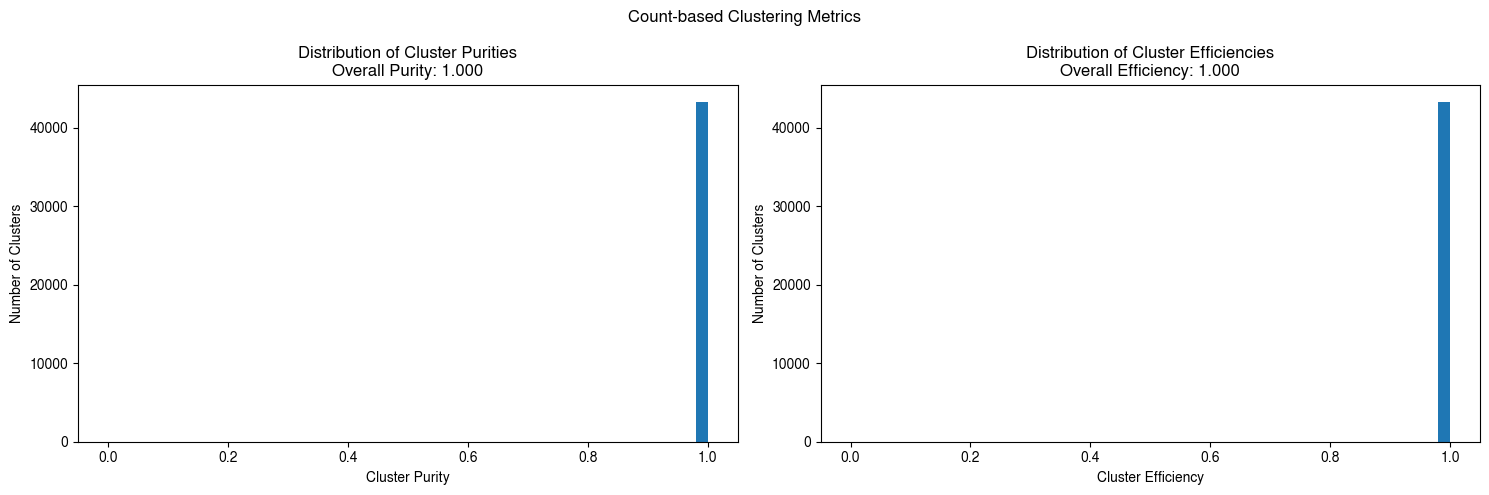

In [71]:
# Basic usage (count-based)
metrics_df, overall = evaluate_clustering(calo_hits_df, label_column='labels_pred', energy_column='energy', particle_id_column='highest_energy_particle_id')

# Plot results
plot_clustering_metrics(metrics_df, overall)

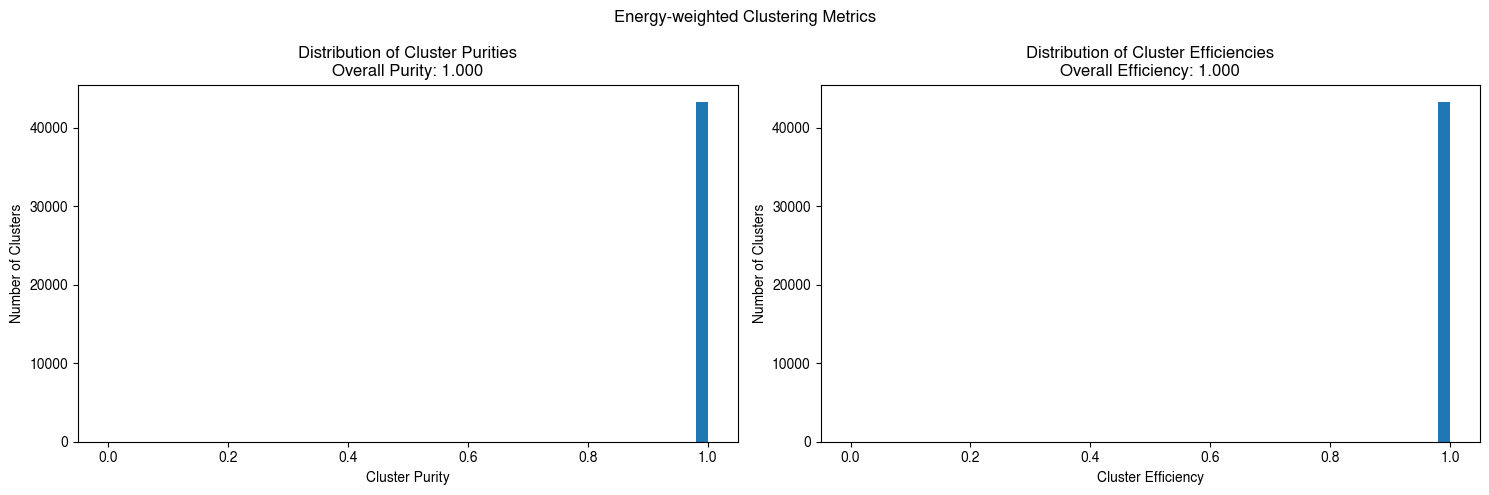

In [72]:
# With energy weighting
metrics_df, overall = evaluate_clustering(calo_hits_df, energy_weighted=True, label_column='labels_pred', energy_column='energy', particle_id_column='highest_energy_particle_id')

# Plot results
plot_clustering_metrics(metrics_df, overall)

In [73]:
# Let's mix up the labels a bit
fraction_to_mix = 0.5
mixed_labels = calo_hits_df.labels_pred.copy()
mixed_labels[np.random.choice(calo_hits_df.index, size=int(len(calo_hits_df)*fraction_to_mix), replace=False)] = np.random.randint(0, int(calo_hits_df.labels_pred.max()), size=int(len(calo_hits_df)*fraction_to_mix))
mixed_labels_df = calo_hits_df.copy()
mixed_labels_df['labels_pred'] = mixed_labels

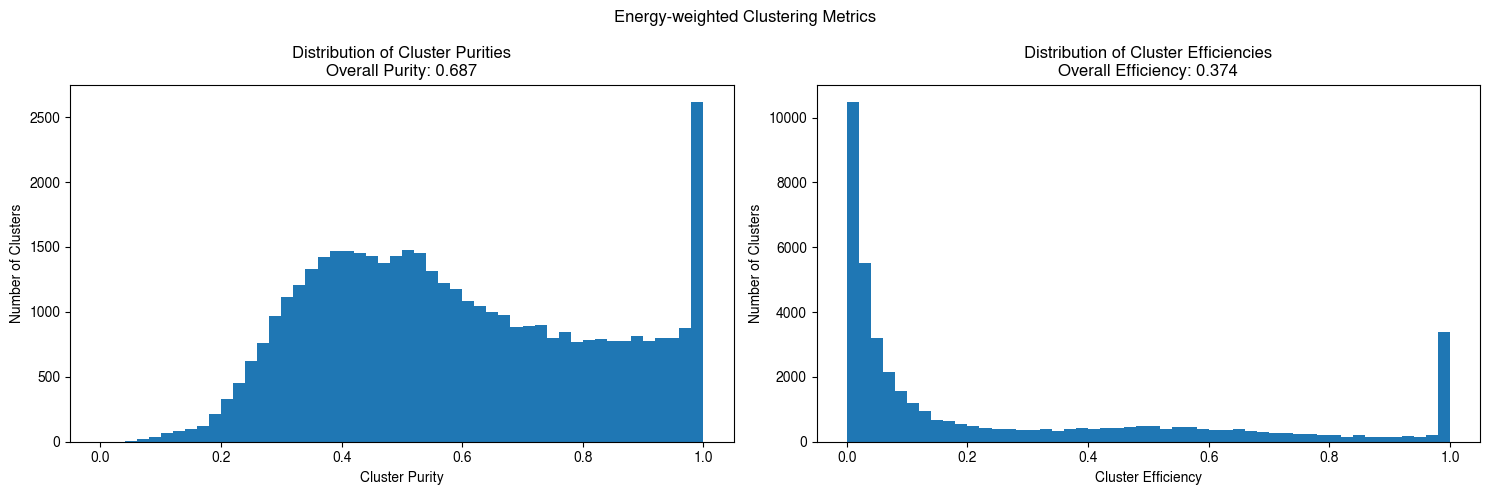

In [75]:
metrics_df, overall = evaluate_clustering(mixed_labels_df, energy_weighted=True, label_column='labels_pred', energy_column='energy', particle_id_column='highest_energy_particle_id')

# Plot results
plot_clustering_metrics(metrics_df, overall)

In [38]:
metrics_df.purity.mean()

0.3245640308047197

In [39]:
metrics_df.efficiency.mean()

0.21667477545642025

In [35]:
overall

{'purity': 0.68296295, 'efficiency': 0.68296295, 'energy_weighted': True}

In [67]:
df = pd.DataFrame({
    'particle_id': [1, 1, 1, 2, 2, 2],
    'cluster_id': [0, 0, 1, 1, 1, 1],  # One cell from particle 1 in cluster 1
    'energy': [1.0, 2.0, 1.0, 4.0, 2.0, 2.0]
})

metrics, overall = evaluate_clustering(
    df, 
    label_column='cluster_id',
    particle_id_column='particle_id',
    energy_column='energy',
    energy_weighted=True
)

In [68]:
metrics

,energy,dominant_particle_id,correct_energy,purity,total_particle_energy,efficiency
cluster_id,,,,,,
0,3.0,1,3.0,1.000000,4.0,0.75
1,9.0,2,8.0,0.888889,8.0,1.00


In [69]:
overall

{'purity': 0.9166666666666666, 'efficiency': 0.9375, 'energy_weighted': True}

### ECal Endcap Collection

In [91]:
edm4hep_file = "/global/cfs/cdirs/m3443/usr/dtmurnane/Side_Work/ACTS/outputs/python_submission_tests/v1_testing/runs/0/edm4hep.root"
# all_events = load_edm4hep_file(edm4hep_file)
event = load_edm4hep_file(edm4hep_file, event_num=0)

In [92]:
event.keys()

dict_keys(['tracker_df', 'calo_hits_df', 'calo_contrib_df', 'particles_df', 'parents_df', 'daughters_df'])

In [93]:
calo_df = event["calo_hits_df"]
particles_df = event["particles_df"]
contrib_df = event["calo_contrib_df"]

In [94]:
calo_df = calo_df[calo_df.detector == 'ECalEndcapCollection']
contrib_df = contrib_df[contrib_df.detector == 'ECalEndcapCollection']

In [95]:
calo_df.cellID.unique().shape

(818162,)

In [96]:
calo_df

,cellID,energy,x,y,z,contribution_begin,contribution_end,r,phi,R,theta,eta,detector
355600,1689210645938705,0.000147,-414.198639,113.588722,-3202.399902,0,1,429.491455,2.873936,3231.072266,3.008273,-2.706667,ECalEndcapCollection
355601,1689210645971473,0.000130,-414.198639,113.588722,-3207.449951,1,2,429.491455,2.873936,3236.077637,3.008480,-2.708229,ECalEndcapCollection
355602,1689210646004241,0.000174,-414.198639,113.588722,-3212.500000,2,3,429.491455,2.873936,3241.083008,3.008687,-2.709790,ECalEndcapCollection
355603,1689210646037009,0.000144,-414.198639,113.588722,-3217.550049,3,4,429.491455,2.873936,3246.088623,3.008893,-2.711345,ECalEndcapCollection
355604,1689210646069777,0.000132,-414.198639,113.588722,-3222.600098,4,5,429.491455,2.873936,3251.094238,3.009099,-2.712900,ECalEndcapCollection
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1173757,59110372183474449,0.000319,521.351013,1195.685303,3293.300049,4110415,4110420,1304.404175,1.159623,3542.216064,0.377121,1.656386,ECalEndcapCollection
1173758,59391842865217809,0.000163,515.354004,1199.692383,3293.300049,4110420,4110432,1305.699707,1.165060,3542.693359,0.377461,1.655463,ECalEndcapCollection
1173759,57702967235543313,0.000141,491.311768,1163.710571,3353.899902,4110432,4110447,1263.174316,1.171305,3583.888184,0.360198,1.703355,ECalEndcapCollection
1173760,57703057429135633,0.001019,596.353882,1184.604736,3242.800049,4110447,4110465,1326.245117,1.104416,3503.523682,0.388225,1.626646,ECalEndcapCollection


In [72]:
calo_df.contribution_begin.describe()

count    8.181620e+05
mean     2.054707e+06
std      1.151517e+06
min      0.000000e+00
25%      1.066240e+06
50%      2.091392e+06
75%      3.039637e+06
max      4.110465e+06
Name: contribution_begin, dtype: float64

In [73]:
calo_df.contribution_end.describe()

count    8.181620e+05
mean     2.054712e+06
std      1.151517e+06
min      1.000000e+00
25%      1.066254e+06
50%      2.091394e+06
75%      3.039638e+06
max      4.110468e+06
Name: contribution_end, dtype: float64

In [74]:
contrib_df

,PDG,energy,time,x,y,z,particle_id,detector
1632720,0,0.000147,13.164886,0.0,0.0,0.0,96703,ECalEndcapCollection
1632721,0,0.000130,13.181981,0.0,0.0,0.0,96703,ECalEndcapCollection
1632722,0,0.000174,13.199089,0.0,0.0,0.0,96703,ECalEndcapCollection
1632723,0,0.000144,13.216205,0.0,0.0,0.0,96703,ECalEndcapCollection
1632724,0,0.000132,13.233321,0.0,0.0,0.0,96703,ECalEndcapCollection
...,...,...,...,...,...,...,...,...
5743183,0,0.000002,3.848731,0.0,0.0,0.0,1850,ECalEndcapCollection
5743184,0,0.000012,3.848741,0.0,0.0,0.0,1850,ECalEndcapCollection
5743185,0,0.000042,3.853139,0.0,0.0,0.0,1850,ECalEndcapCollection
5743186,0,0.000037,3.853551,0.0,0.0,0.0,1850,ECalEndcapCollection


### HCal Barrel Collection

In [75]:
edm4hep_file = "/global/cfs/cdirs/m3443/usr/dtmurnane/Side_Work/ACTS/outputs/python_submission_tests/v1_testing/runs/0/edm4hep.root"
# all_events = load_edm4hep_file(edm4hep_file)
event = load_edm4hep_file(edm4hep_file, event_num=0)

In [76]:
event.keys()

dict_keys(['tracker_df', 'calo_hits_df', 'calo_contrib_df', 'particles_df', 'parents_df', 'daughters_df'])

In [77]:
calo_df = event["calo_hits_df"]
particles_df = event["particles_df"]
contrib_df = event["calo_contrib_df"]

In [78]:
calo_df = calo_df[calo_df.detector == 'HCalBarrelCollection']
contrib_df = contrib_df[contrib_df.detector == 'HCalBarrelCollection']

In [79]:
calo_df.cellID.unique().shape

(92487,)

In [80]:
calo_df.contribution_begin.describe()

count     92487.000000
mean      95523.560965
std       53693.282423
min           0.000000
25%       49388.500000
50%       96970.000000
75%      142225.500000
max      186458.000000
Name: contribution_begin, dtype: float64

In [81]:
calo_df.contribution_end.describe()

count     92487.000000
mean      95525.577022
std       53693.196248
min           1.000000
25%       49390.000000
50%       96973.000000
75%      142228.000000
max      186459.000000
Name: contribution_end, dtype: float64

In [82]:
contrib_df

,PDG,energy,time,x,y,z,particle_id,detector
5743188,0,5.904901e-05,1477.350586,0.0,0.0,0.0,96984,HCalBarrelCollection
5743189,0,6.425006e-05,1477.228149,0.0,0.0,0.0,96984,HCalBarrelCollection
5743190,0,3.395531e-05,1477.229004,0.0,0.0,0.0,96984,HCalBarrelCollection
5743191,0,4.013560e-06,1477.229126,0.0,0.0,0.0,96984,HCalBarrelCollection
5743192,0,1.505803e-05,1477.248535,0.0,0.0,0.0,96984,HCalBarrelCollection
...,...,...,...,...,...,...,...,...
5929642,0,2.820258e-07,1240.522949,0.0,0.0,0.0,1803,HCalBarrelCollection
5929643,0,5.577485e-08,1561.118042,0.0,0.0,0.0,1850,HCalBarrelCollection
5929644,0,1.388218e-09,1597.660156,0.0,0.0,0.0,1850,HCalBarrelCollection
5929645,0,5.089265e-09,1662.150391,0.0,0.0,0.0,1850,HCalBarrelCollection


### HCal Endcap Collection

In [97]:
edm4hep_file = "/global/cfs/cdirs/m3443/usr/dtmurnane/Side_Work/ACTS/outputs/python_submission_tests/v1_testing/runs/0/edm4hep.root"
# all_events = load_edm4hep_file(edm4hep_file)
event = load_edm4hep_file(edm4hep_file, event_num=0)

In [98]:
event.keys()

dict_keys(['tracker_df', 'calo_hits_df', 'calo_contrib_df', 'particles_df', 'parents_df', 'daughters_df'])

In [99]:
calo_df = event["calo_hits_df"]
particles_df = event["particles_df"]
contrib_df = event["calo_contrib_df"]

In [100]:
calo_df = calo_df[calo_df.detector == 'HCalEndcapCollection']
contrib_df = contrib_df[contrib_df.detector == 'HCalEndcapCollection']

In [101]:
calo_df.cellID.unique().shape

(249814,)

In [102]:
calo_df

,cellID,energy,x,y,z,contribution_begin,contribution_end,r,phi,R,theta,eta,detector
1266249,1125947158856212,1.134088e-03,-300.248291,182.074036,-5279.5,0,2,351.140991,2.596472,5291.164551,3.075180,-3.404652,HCalEndcapCollection
1266250,1407422135599636,1.101479e-02,-294.395599,211.497604,-5330.5,2,30,362.491394,2.518616,5342.811035,3.073694,-3.382502,HCalEndcapCollection
1266251,1407426430599700,3.535893e-03,-323.819153,217.350311,-5381.5,30,34,390.000000,2.550452,5395.613281,3.069249,-3.319034,HCalEndcapCollection
1266252,18443084890429817364,2.498954e-03,-23.090818,-423.635223,-5381.5,34,46,424.264038,-1.625249,5398.198242,3.062918,-3.235065,HCalEndcapCollection
1266253,1125831194083860,1.163656e-02,488.335052,-5.372679,-4259.5,46,56,488.364594,-0.011002,4287.404785,3.027438,-2.862263,HCalEndcapCollection
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1516058,9570243703800084,5.097902e-06,448.326141,1129.160645,3698.5,1437042,1437043,1214.907471,1.192841,3892.929688,0.317382,1.832352,HCalEndcapCollection
1516059,10414690108932372,5.436312e-05,577.885803,1246.694824,3953.5,1437043,1437044,1374.117920,1.136744,4185.494141,0.334508,1.778855,HCalEndcapCollection
1516060,11822043517681940,2.135552e-06,401.504486,1364.549072,4004.5,1437044,1437045,1422.392334,1.284633,4249.614258,0.341298,1.758372,HCalEndcapCollection
1516061,12384993471136020,5.875230e-09,389.799072,1423.396240,4055.5,1437045,1437047,1475.804932,1.303498,4315.678223,0.349006,1.735591,HCalEndcapCollection


In [88]:
calo_df.contribution_begin.describe()

count    2.498140e+05
mean     9.451552e+05
std      3.964869e+05
min      0.000000e+00
25%      6.524922e+05
50%      1.057474e+06
75%      1.283760e+06
max      1.437047e+06
Name: contribution_begin, dtype: float64

In [89]:
calo_df.contribution_end.describe()

count    2.498140e+05
mean     9.451609e+05
std      3.964837e+05
min      2.000000e+00
25%      6.524932e+05
50%      1.057476e+06
75%      1.283763e+06
max      1.437048e+06
Name: contribution_end, dtype: float64

In [116]:
contrib_df.iloc[2:30].energy.sum()

0.011014786

In [114]:
particles_df.iloc[96702].daughters_begin, particles_df.iloc[96702].daughters_end


(441882.0, 441884.0)